In [ ]:
library(survival)
library(survminer)
library(dplyr)
library(MASS)
library(car)
library(riskRegression)
library(timeROC)
library(rstpm2)
library(readxl)
library(pec)
library(caret)
library(flexsurv)
library(purrr)
library(tidyr)
library(ggplot2)
library(SurvMetrics)
library(survex)
library(pracma)
library(survRM2)

Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Registered S3 method overwritten by 'riskRegression':
  method        from 
  nobs.multinom broom

riskRegression version 2025.09.17

Loading required package: splines


Attaching package: ‘rstpm2’


The following object is masked from ‘package:survival’:

    colon


Loading required package: prodlim


Attaching package: ‘pec’


The following objects are masked from ‘package:riskRegression’:

  

In [ ]:
data = read.csv("df_support_final_r.csv", 
               header = TRUE, 
               sep = ",", 
               check.names = FALSE)
data_2 = read_excel("df_support_no_dummies.xlsx")

# data_new = read.csv("df_support_final_r_2.csv", 
#                header = TRUE, 
#                sep = ",", 
#                check.names = FALSE)

vars <- c("age", "death", "d.time",
          "scoma", "temp", "sod")

data <- data %>% 
  semi_join(data_2, by = vars)

In [ ]:
# data <- data %>%
#     rename(
#         Usia                        = age,
#         `Hari Masuk`          = hday,
#         `Skor Koma`                 = scoma,
#         `Tekanan Darah`             = meanbp,
#         `Sel Putih`           = wblc,
#         `Detak Jantung`             = hrt,
#         `Laju Pernapasan`           = resp,
#         `Suhu Tubuh`                = temp,
#         `PaO2/FiO2`           = pafi,
#         `Serum Albumin`             = alb,
#         Bilirubin                   = bili,
#         Kreatinin                   = crea,
#         `Natrium Serum`             = sod,
#         `pH Darah Arteri`           = ph,
#         `COPD`          = dzclass_COPD_CHF_Cirrhosis,
#         Kanker                      = dzclass_Cancer,
#         Koma                        = dzclass_Coma,
#         `Metastatik`         = ca_metastatic,
#         `Nonmetastatik`      = ca_yes,
#         `JK_Perempuan`   = sex_female
#     )

# Descriptive Statistics

In [55]:
quantile(data$d.time[data$death == 1], probs = c(0.25, 0.5, 0.75))

25%   50%   75% 
 14.0  58.0 252.5

In [56]:
data %>% count(death)

death,n
<int>,<int>
0,2904
1,6199


In [28]:
table(data_2$sex, data_2$death)
table(data_2$dzclass, data_2$death)
table(data_2$ca, data_2$death)

        
            0    1
  female 1337 2642
  male   1567 3557

                    
                        0    1
  ARF/MOSF           1504 2721
  Cancer              160 1260
  Coma                112  484
  COPD/CHF/Cirrhosis 1128 1734

            
                0    1
  metastatic  199 1659
  no         2405 3588
  yes         300  952

In [41]:
plot_hist_event <- function(data, time_var = "d.time", status_var = "death") {

  # --- Data ---
  t_events <- data[[time_var]][data[[status_var]] == 1]

  # --- Warna & Style ---
  col_bar    <- "#5BAFD6"
  col_border <- "white"

  # --- Batas ---
  breaks <- pretty(t_events, n = 50)
  h      <- hist(t_events, breaks = breaks, plot = FALSE)

  ymax <- max(h$counts) * 1.05

  # --- Plot ---
  par(mgp = c(2.5, 0.8, 0))

  plot(h,
       col      = col_bar,
       border   = col_border,
       main     = "",
       xlab     = "t (hari)",
       ylab     = "n",
       ylim     = c(0, ymax),
       cex.lab  = 1.2,
       cex.axis = 1.4,
       font.lab  = 2,
       font.axis = 2)

  grid(lty = 3, col = "gray85")

  # Redraw bar supaya grid tidak menutupi bar
  plot(h,
       col    = adjustcolor(col_bar, alpha.f = 0.85),
       border = col_border,
       add    = TRUE)

  # --- Outer line ---
  box(col = "grey30", lwd = 1)

  invisible(NULL)
}

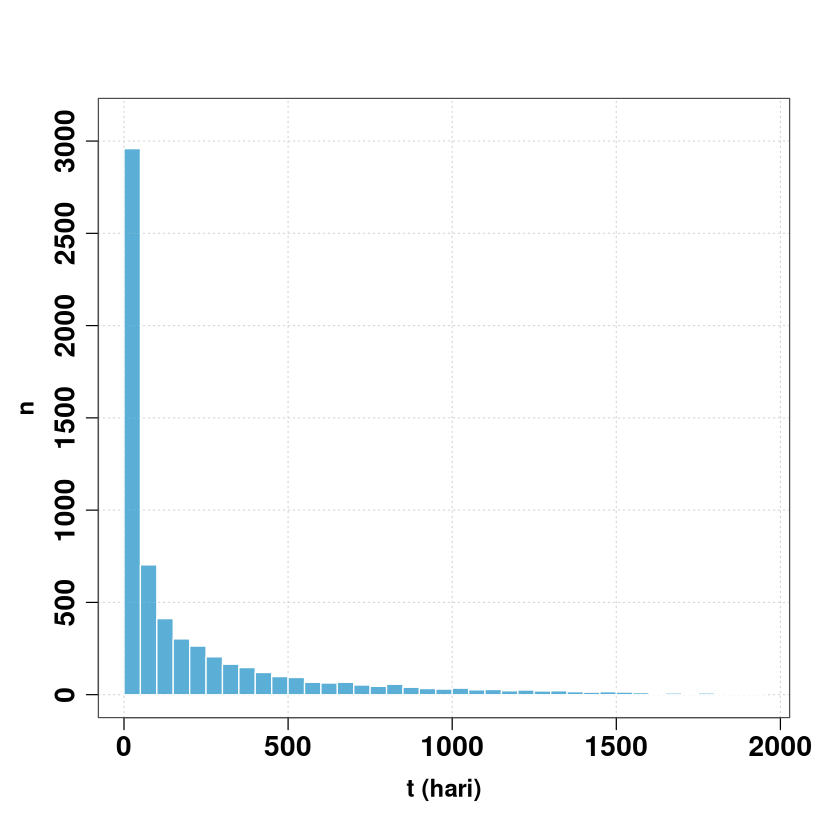

In [42]:
plot_hist_event(data)

In [83]:
# Ambil variabel numerik
data_num <- data[sapply(data, is.numeric)]

# Hitung statistik satu per satu (EKSPLISIT)
statistik <- data.frame(
  Mean = sapply(data_num, mean, na.rm = TRUE),
  Median = sapply(data_num, median, na.rm = TRUE),
  SD = sapply(data_num, sd, na.rm = TRUE),
  
  Q1 = sapply(data_num, quantile, probs = 0.25, na.rm = TRUE),
  Q3 = sapply(data_num, quantile, probs = 0.75, na.rm = TRUE)
)

# DEFINISI IQR (BUKAN LANGSUNG PANGGIL FUNGSI)
statistik$IQR <- statistik$Q3 - statistik$Q1

# Min dan Max
statistik$Min <- sapply(data_num, min, na.rm = TRUE)
statistik$Max <- sapply(data_num, max, na.rm = TRUE)

# Gabung Min–Max
statistik$`Min–Max` <- paste(statistik$Min, statistik$Max, sep = "–")

# Bersihkan kolom yang tidak dipakai
statistik$Q1 <- NULL
statistik$Q3 <- NULL
statistik$Min <- NULL
statistik$Max <- NULL

# Lihat hasil
statistik

,Mean,Median,SD,IQR,Min–Max
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
age,62.65161977,64.859990,15.59524412,21.2074700,18.04199–101.84796
hday,4.40074701,1.000000,9.12767466,2.0000000,1–148
scoma,12.05987037,0.000000,24.63772310,9.0000000,0–100
meanbp,84.54965396,77.000000,27.68748054,44.0000000,0–195
wblc,12.26999780,10.398438,9.17264862,8.0996094,0–200
hrt,97.15530026,100.000000,31.56073831,48.0000000,0–300
resp,23.33011095,24.000000,9.57431134,10.0000000,0–90
temp,37.10347343,36.695310,1.25180059,2.0000000,31.69922–41.69531
pafi,263.45852941,276.187500,103.09508691,153.5187500,12–890.375


# KM Estimation

In [40]:
# Overall Kaplan-Meier Curve
surv_object = Surv(time = data$d.time, event = data$death)
fit_overall = survfit(surv_object ~ 1, data = data)
fit_overall

Call: survfit(formula = surv_object ~ 1, data = data)

        n events median 0.95LCL 0.95UCL
[1,] 9103   6199    233     217     252

In [13]:
summary(fit_overall)

Call: survfit(formula = surv_object ~ 1, data = data)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    3   9103     137    0.985 0.00128        0.982        0.987
    4   8966     238    0.959 0.00208        0.955        0.963
    5   8728     194    0.937 0.00254        0.933        0.942
    6   8534     155    0.920 0.00284        0.915        0.926
    7   8379     180    0.901 0.00313        0.895        0.907
    8   8199     144    0.885 0.00335        0.878        0.891
    9   8055     119    0.872 0.00350        0.865        0.879
   10   7936     107    0.860 0.00364        0.853        0.867
   11   7829     105    0.849 0.00376        0.841        0.856
   12   7724      74    0.840 0.00384        0.833        0.848
   13   7650      67    0.833 0.00391        0.825        0.841
   14   7583      88    0.823 0.00400        0.816        0.831
   15   7495      73    0.815 0.00407        0.807        0.823
   16   7422      58    0.809 0.00412        0.80

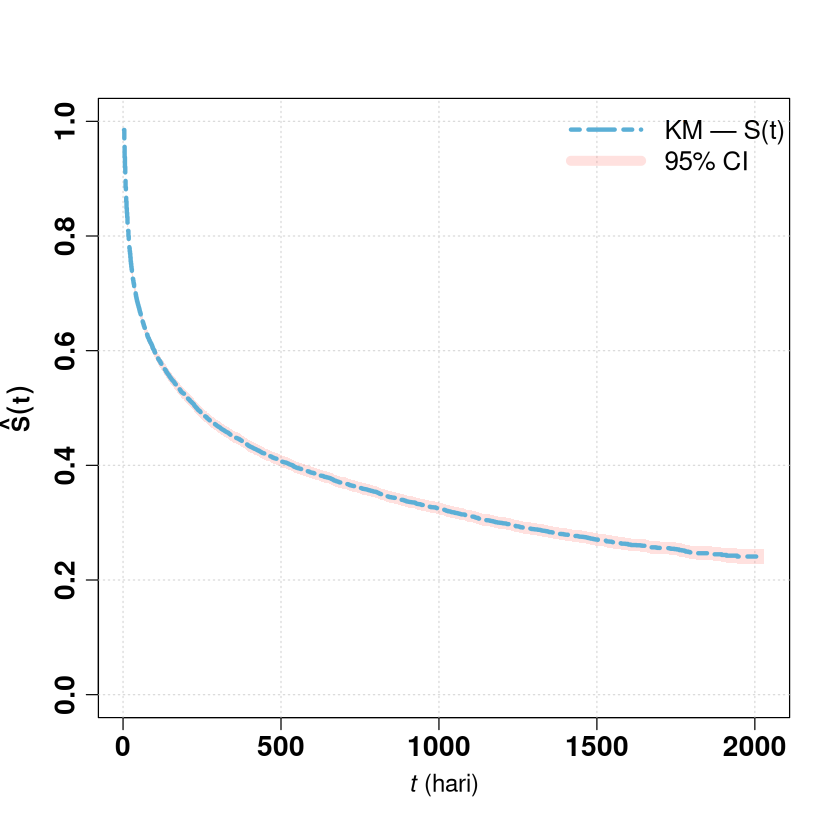

In [29]:
# --- Warna & Style ---
col_line <- "#5BAFD6"
col_ci   <- adjustcolor("#ff6961", alpha.f = 0.20)
col_bg   <- "gray85"

lty_line <- 6
lwd_line <- 3.5

# --- Data KM ---
km_data <- data.frame(
  time  = fit_overall$time,
  surv  = fit_overall$surv,
  lower = fit_overall$lower,
  upper = fit_overall$upper
)

# ============================================================
# PLOT 1: S(t) Kaplan-Meier
# ============================================================
par(mgp = c(2.5, 0.8, 0))

plot(km_data$time, km_data$surv,
     type     = "n",
     xlab     = expression(italic(t) ~ "(hari)"),
     ylab     = expression(bold(hat(S)(t))),
     ylim     = c(0, 1),
     cex.lab  = 1.2,
     cex.axis = 1.4,
     font.lab  = 2,
     font.axis = 2)

grid(lty = 3, col = "gray85")

# Ribbon CI
polygon(c(km_data$time, rev(km_data$time)),
        c(km_data$upper, rev(km_data$lower)),
        col    = col_ci,
        border = NA)

# Step function S(t)
lines(km_data$time, km_data$surv,
      type = "s",       # <-- step function
      col  = col_line,
      lwd  = lwd_line,
      lty  = lty_line)

legend("topright",
       legend  = c("KM — S(t)", "95% CI"),
       col     = c(col_line, col_ci),
       lty     = c(lty_line, 1),
       lwd     = c(lwd_line, 8),
       bty     = "n",
       cex     = 1.3,
       seg.len = 3)

# Cox Model Fit

In [4]:
cox_model = coxph(Surv(d.time, death) ~ ., data = data, x = TRUE, y = TRUE, method = "efron")

In [5]:
royston(cox_model)

D      se(D)        R.D       R.KO        R.N       C.GH 
1.03727569 0.02276119 0.20436768 0.18943706 0.20699059 0.65441928

In [101]:
summary(cox_model)

Call:
coxph(formula = Surv(d.time, death) ~ ., data = data, x = TRUE, 
    y = TRUE, method = "efron")

  n= 9103, number of events= 6199 

                        coef  exp(coef)   se(coef)      z Pr(>|z|)    
Usia               1.570e-02  1.016e+00  9.090e-04 17.272  < 2e-16 ***
`Hari Masuk`       1.171e-02  1.012e+00  1.194e-03  9.802  < 2e-16 ***
`Skor Koma`        1.636e-02  1.016e+00  6.188e-04 26.446  < 2e-16 ***
`Tekanan Darah`   -2.880e-03  9.971e-01  4.907e-04 -5.869 4.38e-09 ***
`Sel Putih`        1.845e-03  1.002e+00  1.420e-03  1.299 0.193848    
`Detak Jantung`    1.992e-03  1.002e+00  4.538e-04  4.389 1.14e-05 ***
`Laju Pernapasan`  2.366e-03  1.002e+00  1.391e-03  1.701 0.088994 .  
`Suhu Tubuh`      -3.514e-02  9.655e-01  1.123e-02 -3.130 0.001751 ** 
`PaO2/FiO2`       -7.736e-05  9.999e-01  1.355e-04 -0.571 0.568181    
`Serum Albumin`   -1.147e-02  9.886e-01  1.856e-02 -0.618 0.536322    
Bilirubin          1.635e-02  1.016e+00  2.689e-03  6.081 1.20e-09 ***
Kreatini

# Schoenfeld Residual Test

In [102]:
schoenfeld_residual_test = cox.zph(cox_model,transform = "km")
schoenfeld <- as.data.frame(schoenfeld_residual_test$table) %>%
  arrange(desc(chisq))
schoenfeld

,chisq,df,p
,<dbl>,<dbl>,<dbl>
GLOBAL,1102.625234,20,4.874454e-221
`Skor Koma`,574.748655,1,5.204321e-127
Kanker,378.729380,1,2.352861e-84
Metastatik,296.672916,1,1.748413e-66
Koma,219.473590,1,1.178169e-49
COPD,181.782007,1,1.978546e-41
`PaO2/FiO2`,130.076948,1,3.941964e-30
Bilirubin,74.784594,1,5.249778e-18
`Serum Albumin`,67.266932,1,2.371255e-16


In [104]:
plots <- ggcoxzph(
    schoenfeld_residual_test,
    font.main = c(6, "plain", "black"),   # title strip kecil
    font.x    = c(5, "plain", "black"),   # label sumbu x
    font.y    = c(8, "plain", "black"),   # label sumbu y
    font.tickslab = c(4, "plain"),         # angka tick axis
    ggtheme = theme_bw(base_size = 5),
    ncol = 4,
    nrow = 5
)

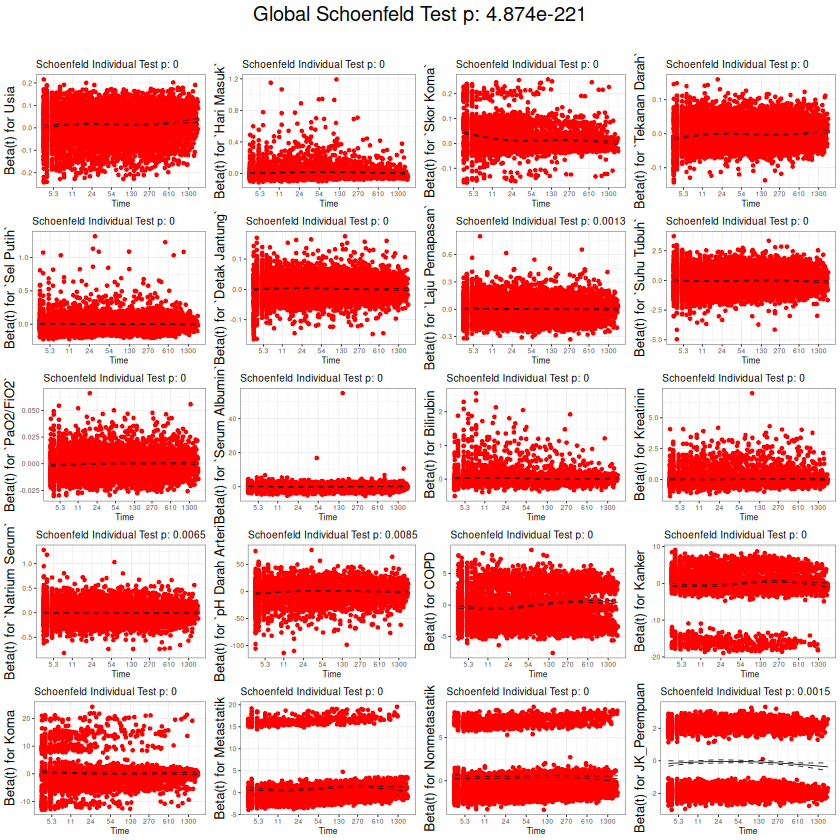

In [105]:
plots

In [106]:
png("schoenfeld_plot.png", width = 18, height = 24, units = "cm", res = 300)
print(plots)
dev.off()

pdf 
  2

In [28]:
plot_schoenfeld <- function(cox_model, var_index) {

  test_ph <- cox.zph(cox_model)

  # Ambil nama variabel
  var_name <- rownames(test_ph$table)[var_index]

  par(mar = c(5, 6, 4, 2)) 

  plot(test_ph[var_index], 
       lwd = 2,
       col = "blue",
       resid = TRUE,
       pch = 1,
       main = paste("Schoenfeld Residual Plot for", var_name),
       xlab = expression(bold(paste("Time (", italic(t), ")"))), 
       ylab = bquote(bold(beta(.(var_name))(t))))

  abline(h = 0, lty = 2, col = "red", lwd = 2)

  legend("topright",
         legend = c("Observed Residuals",
                    "Smoothing Spline",
                    "Null Hypothesis (PH Holds)"),
         col = c("grey70", "blue", "red"),
         lty = c(NA, 1, 2),
         pch = c(1, NA, NA),
         lwd = c(NA, 2, 2),
         cex = 0.8,
         bg = "white")
}


In [4]:
colnames(data)

[1] "age"                        "hday"                      
 [3] "scoma"                      "meanbp"                    
 [5] "wblc"                       "hrt"                       
 [7] "resp"                       "temp"                      
 [9] "pafi"                       "alb"                       
[11] "bili"                       "crea"                      
[13] "sod"                        "ph"                        
[15] "d.time"                     "death"                     
[17] "dzclass_COPD_CHF_Cirrhosis" "dzclass_Cancer"            
[19] "dzclass_Coma"               "ca_metastatic"             
[21] "ca_yes"                     "sex_female"

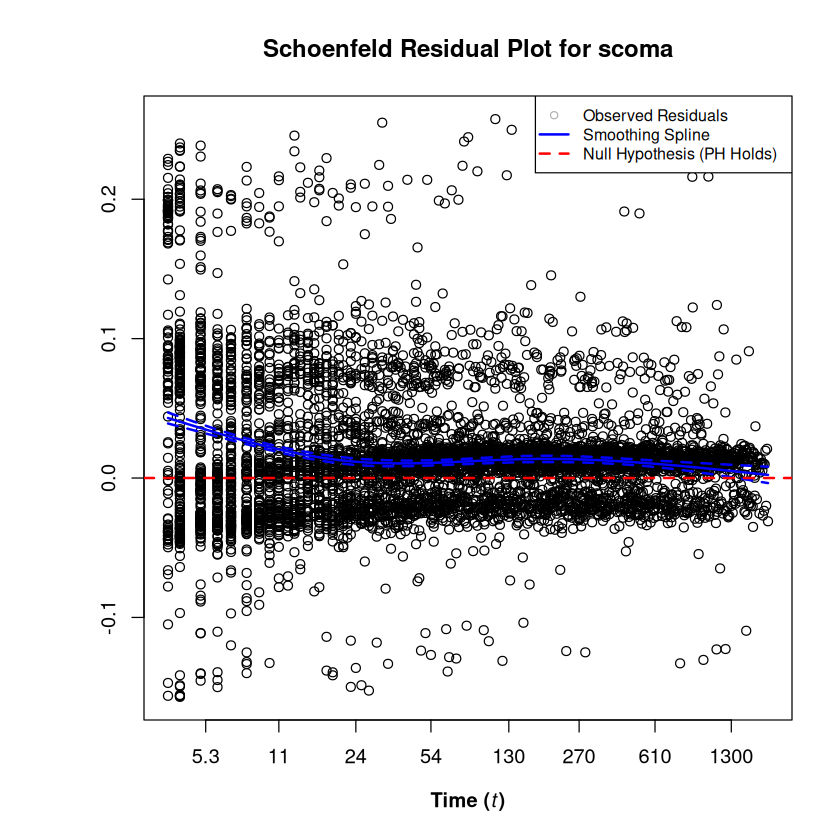

In [42]:
plot_schoenfeld(cox_model, 3)

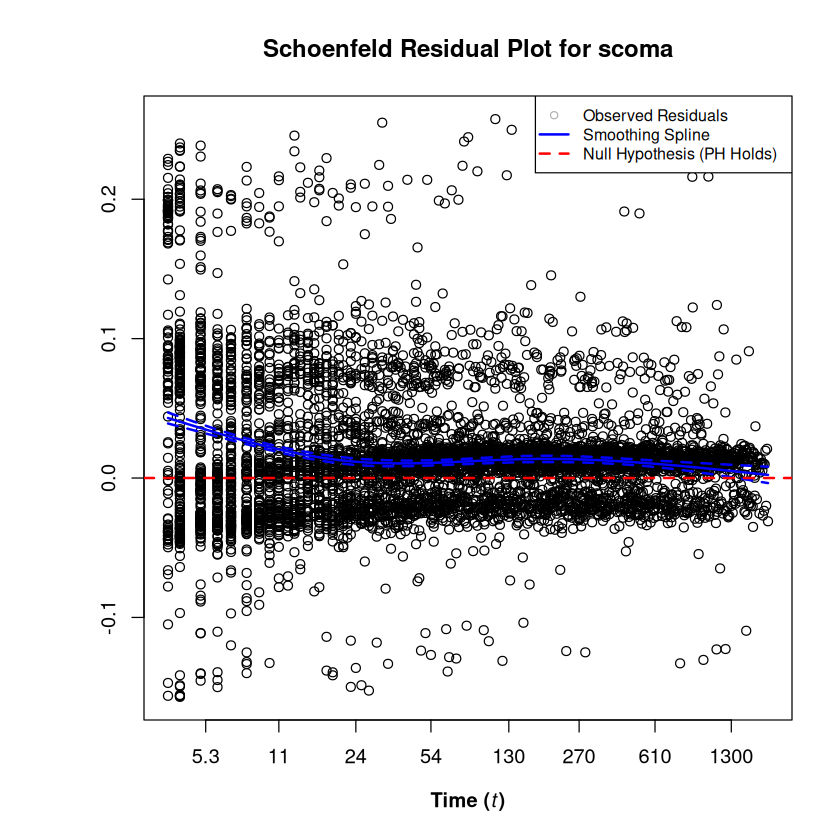

In [32]:
plot_schoenfeld(cox_model, 3)

# FPSM

In [6]:
varnames <- setdiff(names(data), c("d.time", "death"))
formula_str <- as.formula(paste("Surv(d.time, death) ~", paste(varnames, collapse = " + ")))
fpsm_5 = stpm2(formula_str, df = 5, data = data)

In [7]:
fpsm_1 = stpm2(formula_str, df = 1, data = data)
fpsm_2 = stpm2(formula_str, df = 2, data = data)
fpsm_3 = stpm2(formula_str, df = 3, data = data)
fpsm_4 = stpm2(formula_str, df = 4, data = data)

In [16]:
dfs <- 1:10

fpsm_models <- lapply(dfs, function(d) {
  tryCatch(
    stpm2(formula_str, df = d, data = data),
    error = function(e) NULL
  )
})

names(fpsm_models) <- paste0("df_", dfs)

aic_bic_table <- data.frame(
  df  = dfs,
  AIC = sapply(fpsm_models, function(m) if (!is.null(m)) AIC(m) else NA),
  BIC = sapply(fpsm_models, function(m) if (!is.null(m)) BIC(m) else NA)
)

# Tambah delta AIC dan delta BIC
aic_bic_table$delta_AIC <- c(NA, -diff(aic_bic_table$AIC))
aic_bic_table$delta_BIC <- c(NA, -diff(aic_bic_table$BIC))

aic_bic_table

,df,AIC,BIC,delta_AIC,delta_BIC
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
df_1,1,84354.77,84511.33,NA,NA
df_2,2,83220.74,83384.42,1134.032641,1126.916281
df_3,3,82587.87,82758.66,632.873159,625.756800
df_4,4,82385.93,82563.84,201.933305,194.816945
df_5,5,82279.61,82464.63,106.326528,99.210168
df_6,6,82205.91,82398.05,73.701422,66.585062
df_7,7,82143.35,82342.60,62.559699,55.443340
df_8,8,82113.69,82320.06,29.655725,22.539366
df_9,9,82083.02,82296.51,30.667383,23.551023


In [30]:
# ================================================================
# FUNGSI R² UNTUK SURVIVAL MODELS
# Berdasarkan Royston (2006), The Stata Journal 6(1): 83-96
# Versi: semua input manual — meminimalisir error
# ================================================================

calc_X2 <- function(ll_model, ll_null) {
  2 * (ll_model - ll_null)
}

calc_rho2_nagelkerke <- function(X2, n) {
  1 - exp(-X2 / n)
}

calc_rho2_k <- function(X2, e) {
  1 - exp(-X2 / e)
}

calc_R2 <- function(rho2_k) {
  V <- rho2_k / (1 - rho2_k)
  V / (pi^2/6 + V)
}

calc_R2D <- function(D, model_type = "PH") {
  kappa  <- sqrt(8 / pi)
  sigma2 <- switch(model_type,
    "PH"                = pi^2 / 6,
    "probit"            = 1,
    "proportional_odds" = pi^2 / 3
  )
  A <- D^2 / kappa^2
  A / (sigma2 + A)
}

calc_R2D_CI <- function(D, D_se, model_type = "PH", alpha = 0.05) {
  z    <- qnorm(1 - alpha/2)
  D_lb <- D - z * D_se
  D_ub <- D + z * D_se
  list(
    R2D   = calc_R2D(D,    model_type),
    lower = calc_R2D(D_lb, model_type),
    upper = calc_R2D(D_ub, model_type)
  )
}

# ================================================================
# FUNGSI UTAMA — semua input manual
# ================================================================
royston_r2 <- function(ll_model,      # log-likelihood model
                       ll_null,       # log-likelihood null model
                       n_events,      # jumlah events
                       n_obs,         # jumlah observasi
                       D    = NULL,   # D statistic (opsional)
                       D_se = NULL,   # SE of D (opsional)
                       model_type = "PH",  # "PH", "probit", "proportional_odds"
                       alpha = 0.05,
                       label = "") {  # label bebas, misal "Cox PH"

  X2     <- calc_X2(ll_model, ll_null)
  rho2_n <- calc_rho2_nagelkerke(X2, n_obs)
  rho2_k <- calc_rho2_k(X2, n_events)
  R2     <- calc_R2(rho2_k)

  R2D <- NULL
  CI  <- NULL
  if (!is.null(D)) {
    R2D <- calc_R2D(D, model_type)
    if (!is.null(D_se))
      CI <- calc_R2D_CI(D, D_se, model_type, alpha)
  }

  # Print
  cat("=================================================\n")
  if (nchar(label) > 0)
    cat(sprintf("  Model: %s\n", label))
  cat(sprintf("  N observasi : %d\n", n_obs))
  cat(sprintf("  N events    : %d\n", n_events))
  cat(sprintf("  X²          : %.4f\n", X2))
  cat("-------------------------------------------------\n")
  cat(sprintf("  rho²_n  : %.4f  [Nagelkerke 1991]\n", rho2_n))
  cat(sprintf("  rho²_k  : %.4f  [O'Quigley 2005 — explained randomness]\n", rho2_k))
  cat(sprintf("  R²      : %.4f  [Royston 2006 eq.(6) — explained variation]\n", R2))
  if (!is.null(R2D)) {
    cat(sprintf("  D       : %.4f  (SE = %.4f)\n", D, ifelse(is.null(D_se), NA, D_se)))
    cat(sprintf("  R²_D    : %.4f  [Royston & Sauerbrei 2004]\n", R2D))
    if (!is.null(CI))
      cat(sprintf("  95%% CI  : [%.4f, %.4f]\n", CI$lower, CI$upper))
  }
  if (model_type != "PH")
    cat("  Catatan: non-PH — R² adalah rough-and-ready index.\n")
  cat("=================================================\n")

  invisible(list(
    X2 = X2, n_obs = n_obs, n_events = n_events,
    rho2_n = rho2_n, rho2_k = rho2_k, R2 = R2,
    D = D, D_se = D_se, R2D = R2D, R2D_CI = CI
  ))
}

In [33]:
hasil_cox <- royston_r2(
  ll_model   = -52070.6756625821,   # ganti dengan cox_model$loglik[2]
  ll_null    = -53126.2502973061,   # ganti dengan cox_model$loglik[1]
  n_events   = 6199,        # ganti dengan cox_model$nevent
  n_obs      = 9103,        # ganti dengan nrow(df)
  D          = 1.03727569232984,     # dari royston(cox_model)["D"]
  D_se       = 0.0227611911146809,     # dari royston(cox_model)["se(D)"]
  model_type = "PH",
  label      = "Cox PH"
)

  Model: Cox PH
  N observasi : 9103
  N events    : 6199
  X²          : 2111.1493
-------------------------------------------------
  rho²_n  : 0.2070  [Nagelkerke 1991]
  rho²_k  : 0.2886  [O'Quigley 2005 — explained randomness]
  R²      : 0.1979  [Royston 2006 eq.(6) — explained variation]
  D       : 1.0373  (SE = 0.0228)
  R²_D    : 0.2044  [Royston & Sauerbrei 2004]
  95% CI  : [0.1904, 0.2184]


In [34]:
royston(cox_model)

D      se(D)        R.D       R.KO        R.N       C.GH 
1.03727569 0.02276119 0.20436768 0.18943706 0.20699059 0.65441928

In [ ]:
hasil_fpsm_ph <- royston_r2(
  ll_model   = -41113.8 ,   # ganti dengan as.numeric(logLik(fpsm_ph))
  ll_null    = -42174.37 ,   # ganti dengan as.numeric(logLik(fpsm_null))
  n_events   = 6199,
  n_obs      = 9103,
  model_type = "PH",
  label      = "FPSM-PH"
)

  Model: FPSM-PH
  N observasi : 9103
  N events    : 6199
  X²          : 2121.1400
-------------------------------------------------
  rho²_n  : 0.2079  [Nagelkerke 1991]
  rho²_k  : 0.2898  [O'Quigley 2005 — explained randomness]
  R²      : 0.1987  [Royston 2006 eq.(6) — explained variation]


In [50]:
round(AIC(fpsm_time),2)
round(BIC(fpsm_time),2)

[1] 81032.52

[1] 81302.94

In [44]:
hasil_fpsm_tde <- royston_r2(
  ll_model   = -40478.26 ,   # ganti dengan as.numeric(logLik(fpsm_tde))
  ll_null    = -42174.37,   # null sama dengan FPSM-PH
  n_events   = 6199,
  n_obs      = 9103,
  model_type = "PH",       # baseline tetap PH
  label      = "FPSM-TDE"
)

  Model: FPSM-TDE
  N observasi : 9103
  N events    : 6199
  X²          : 3392.2200
-------------------------------------------------
  rho²_n  : 0.3111  [Nagelkerke 1991]
  rho²_k  : 0.4214  [O'Quigley 2005 — explained randomness]
  R²      : 0.3069  [Royston 2006 eq.(6) — explained variation]


In [13]:
plot_fpsm_spline_overlay <- function(models, t_seq, data) {

  # --- Warna & Style ---
  cols <- c(
  "#E41A1C",  # df = 1 — merah
  "#FF8C00",  # df = 2 — oranye
  "#4DAF4A",  # df = 3 — hijau
  "#9B59B6",  # df = 4 — ungu
  "#1A1A1A" ,  # df = 5 — hitam
  "#FFD700"   # df = 6 — emas
)
  lty_line <- 6
  lwd_line <- 3.5

  # --- Base data ---
  base_data <- data.frame(
    d.time = t_seq,
    age = 0, hday = 0, scoma = 0,
    meanbp = 0, wblc = 0, hrt = 0, temp = 0, resp = 0,
    pafi = 0, alb = 0, bili = 0, crea = 0,
    sod = 0, ph = 0, dzclass_COPD_CHF_Cirrhosis = 0,
    dzclass_Cancer = 0, dzclass_Coma = 0, ca_metastatic = 0,
    ca_yes = 0, sex_female = 0
  )

  # --- Hitung prediksi semua model ---
  log_time <- log(t_seq)

  preds <- lapply(models, function(m) {
    as.vector(predict(m, newdata = base_data, type = "link"))
  })

  # --- Batas y global ---
  ymin <- min(sapply(preds, min, na.rm = TRUE)) * 1.05
  ymax <- max(sapply(preds, max, na.rm = TRUE)) * 1.05

  # --- Plot dasar ---
  par(mgp = c(2.5, 0.8, 0))

  plot(log_time, preds[[1]],
       type     = "n",
       xlab     = expression(ln(t)),
       ylab     = expression(italic(s)*"["*ln(t)*" | "*gamma*","*kappa*"]"),
       ylim     = c(ymin, ymax),
       cex.lab  = 1.2,
       cex.axis = 1.4,
       font.lab  = 2,
       font.axis = 2)

  grid(lty = 3, col = "gray85")

  # --- Overlay semua garis ---
  for (i in seq_along(models)) {
    lines(log_time, preds[[i]],
          col = cols[i],
          lwd = lwd_line,
          lty = lty_line)
  }

  # --- Legend ---
  legend("topleft",
         legend  = paste0("df = ", seq_along(models)),
         col     = cols[seq_along(models)],
         lty     = lty_line,
         lwd     = lwd_line,
         bty     = "n",
         cex     = 1.3,
         seg.len = 3)

  invisible(NULL)
}

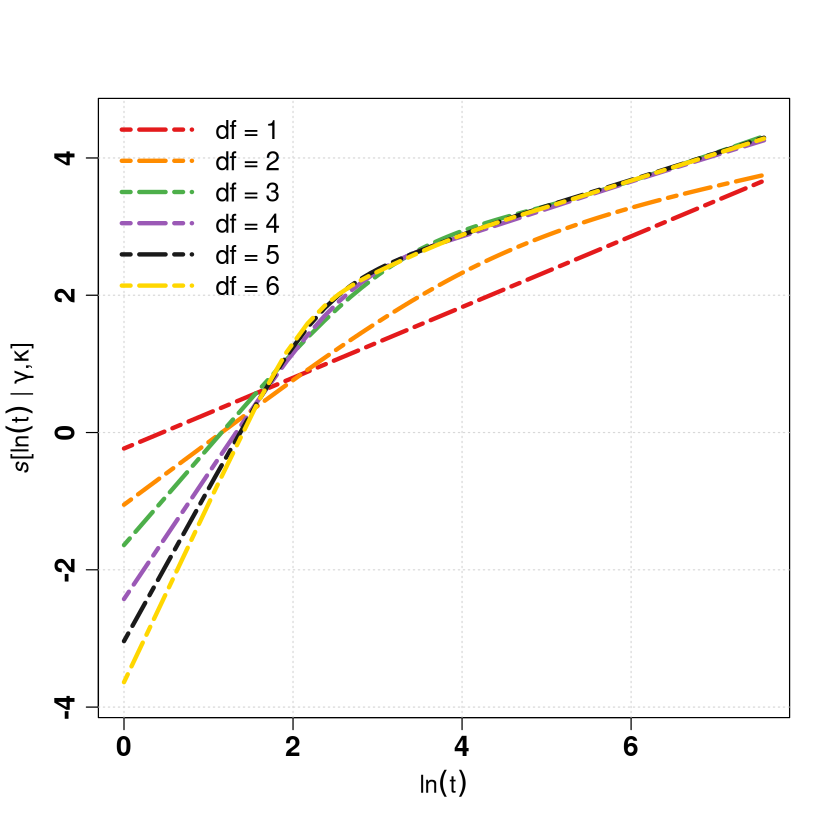

In [14]:
plot_fpsm_spline_overlay(
  models = list(fpsm_1, fpsm_2, fpsm_3, fpsm_4, fpsm_5, fpsm_6),
  t_seq  = seq(1, 1944, length.out = 1000),
  data   = data
)

In [6]:
plot_fpsm_spline <- function(model, df, knots_internal = NULL, t_seq, data) {

  # --- Warna & Style ---
  col_line <- "#5BAFD6"
  col_knot <- "gray40"

  lty_line <- 6
  lty_knot <- 5
  lwd_line <- 3.5
  lwd_knot <- 1.5

  # --- Data ---
  t_events <- data$d.time[data$death == 1]
  ln_t_min <- log(min(t_events))
  ln_t_max <- log(max(t_events))

  base_data <- data.frame(
    d.time = t_seq,
    age = 0, hday = 0, scoma = 0,
    meanbp = 0, wblc = 0, hrt = 0, temp = 0, resp = 0,
    pafi = 0, alb = 0, bili = 0, crea = 0,
    sod = 0, ph = 0, dzclass_COPD_CHF_Cirrhosis = 0,
    dzclass_Cancer = 0, dzclass_Coma = 0, ca_metastatic = 0,
    ca_yes = 0, sex_female = 0
  )

  pred <- predict(model, newdata = base_data, type = "link")

  log_time    <- log(t_seq)
  log_cum_haz <- as.vector(pred)

  # --- Batas y ---
  ymin <- min(log_cum_haz, na.rm = TRUE) * 1.05
  ymax <- max(log_cum_haz, na.rm = TRUE) * 1.05

  # --- Plot dasar ---
  par(mgp = c(2.5, 0.8, 0))

  plot(log_time, log_cum_haz,
       type     = "n",
       xlab     = expression(ln(t)),
       ylab     = expression(italic(s)*"["*ln(t)*" | "*gamma*","*kappa*"]"),
       ylim     = c(ymin, ymax),
       cex.lab  = 1.2,
       cex.axis = 1.4,
       font.lab  = 2,
       font.axis = 2)

  # Grid background
  grid(lty = 3, col = "gray85")

  # --- Garis spline ---
  lines(log_time, log_cum_haz,
        col = col_line,
        lwd = lwd_line,
        lty = lty_line)

  # --- Knots ---
  if (df > 1 && !is.null(knots_internal)) {
    all_knots <- c(ln_t_min, knots_internal, ln_t_max)

    for (k in all_knots) {
      abline(v   = k,
             col = col_knot,
             lwd = lwd_knot,
             lty = lty_knot)
    }
  }

  # --- Legend ---
  if (df > 1 && !is.null(knots_internal)) {
    legend("topleft",
           legend  = c(paste0("df = ", df),
                       paste0("Knot (n = ", length(all_knots), ")")),
           col     = c(col_line, col_knot),
           lty     = c(lty_line, lty_knot),
           lwd     = c(lwd_line, lwd_knot),
           bty     = "n",
           cex     = 1.3,
           seg.len = 3)
  } else {
    legend("topleft",
           legend  = paste0("df = ", df),
           col     = col_line,
           lty     = lty_line,
           lwd     = lwd_line,
           bty     = "n",
           cex     = 1.3,
           seg.len = 3)
  }

  invisible(NULL)
}

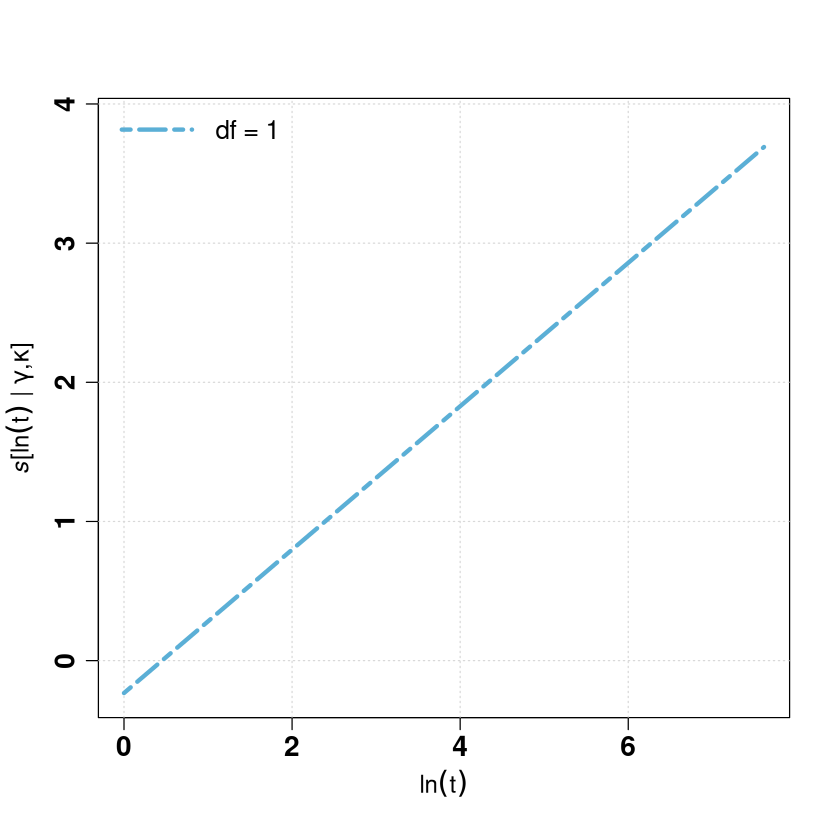

In [7]:
# df = 1
plot_fpsm_spline(model = fpsm_1, df = 1, 
                 knots_internal = NULL,
                 t_seq = seq(1, max(data$d.time), by = 1), 
                 data = data)

In [11]:
t_events = data$d.time[data$death == 1]

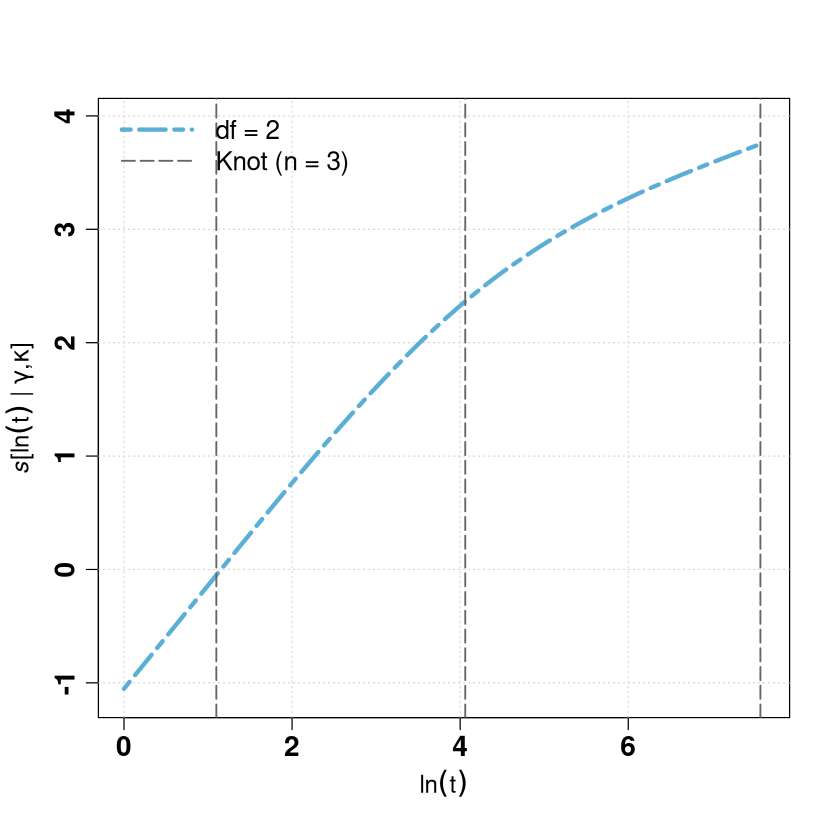

In [18]:
# df = 2
plot_fpsm_spline(model = fpsm_2, df = 2,
                 knots_internal = quantile(log(t_events), c(0.50)),
                 t_seq = seq(1, max(data$d.time), by = 1),
                 data = data)

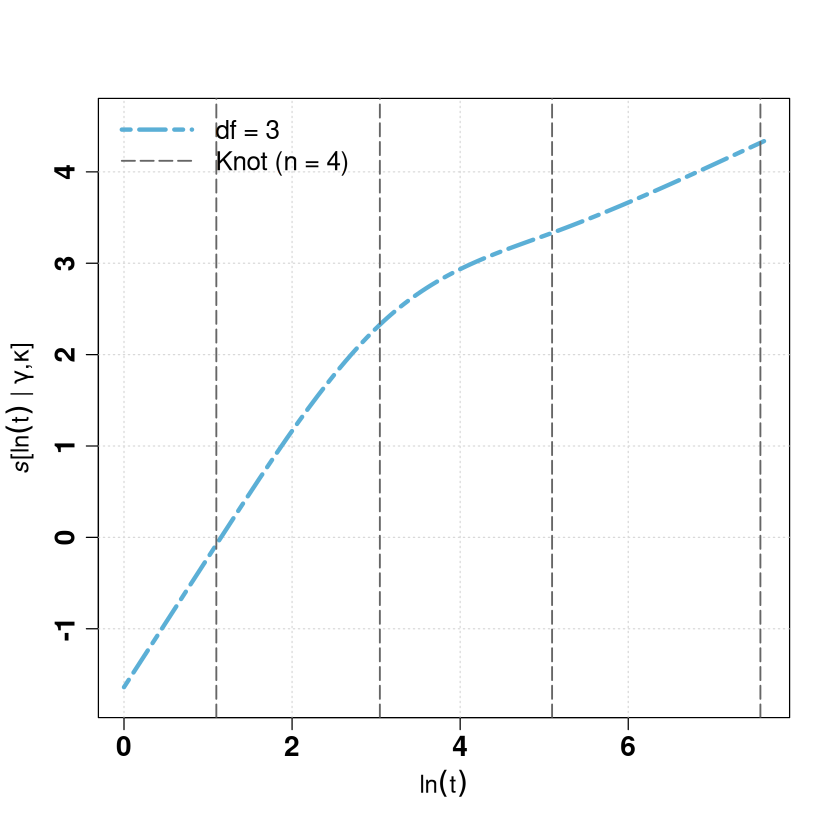

In [19]:
plot_fpsm_spline(
  model    = fpsm_3,
  df       = 3,
  knots_internal = quantile(log(t_events), c(0.33, 0.67)),  # ln(t) untuk Q50 uncensored event times
  t_seq    = seq(1, max(data$d.time), by = 1),
  data     = data
)

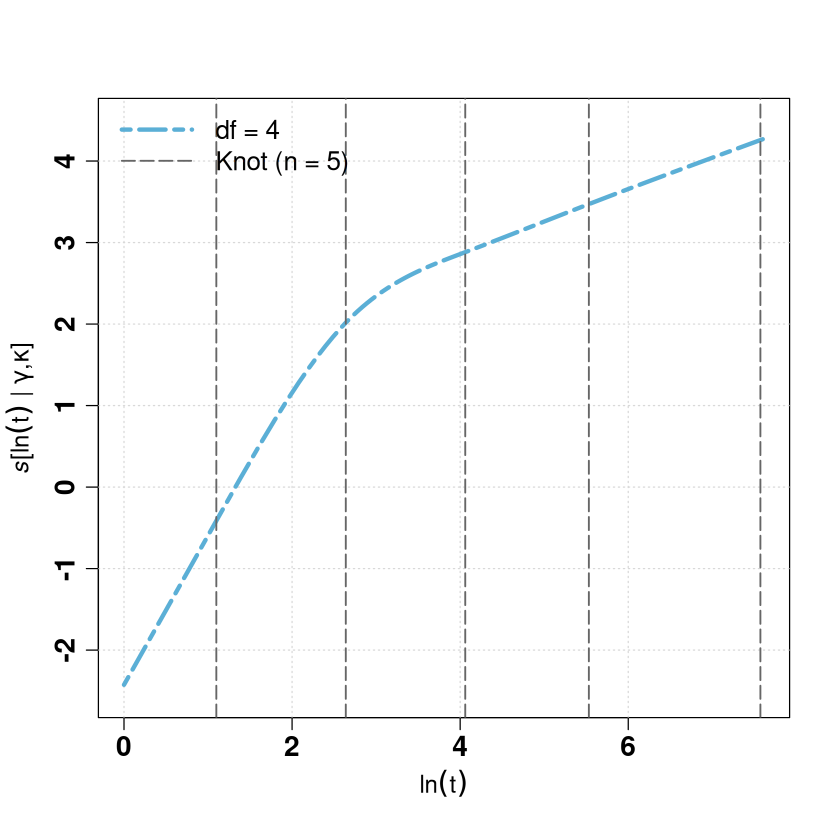

In [20]:
plot_fpsm_spline(
  model    = fpsm_4,
  df       = 4,
  knots_internal = quantile(log(t_events), c(0.25, 0.50, 0.75)),  # ln(t) untuk Q50 uncensored event times
  t_seq    = seq(1, max(data$d.time), by = 1),
  data     = data
)

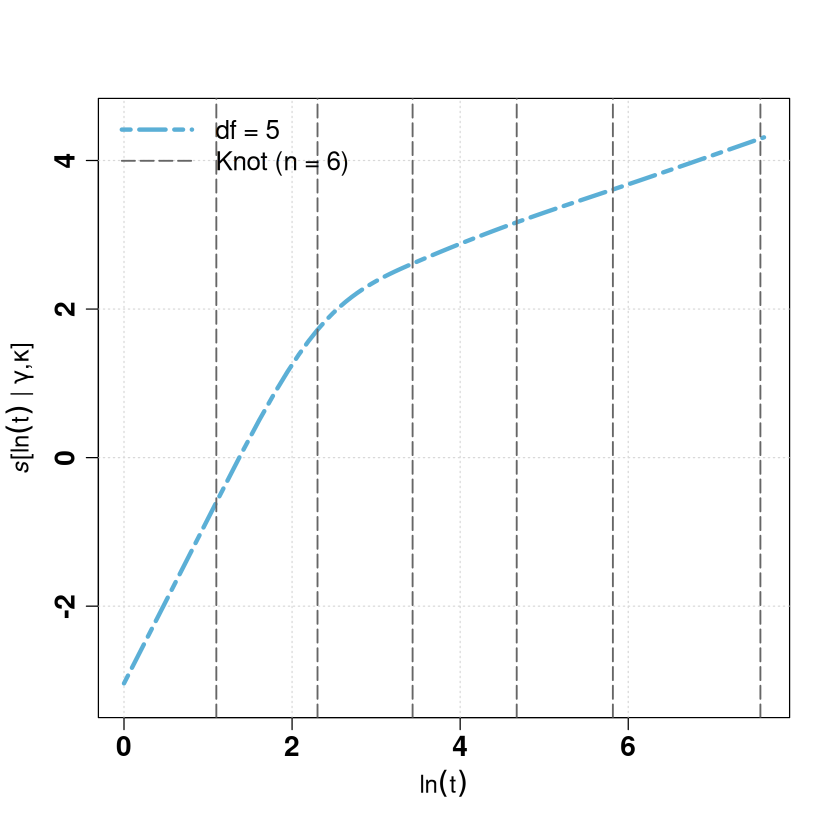

In [21]:
plot_fpsm_spline(
  model    = fpsm_5,
  df       = 5,
  knots_internal = quantile(log(t_events), c(0.20, 0.40, 0.60, 0.80)),  # ln(t) untuk Q50 uncensored event times
  t_seq    = seq(1, max(data$d.time), by = 1),
  data     = data
)

In [13]:
summary(fpsm_5)

Maximum likelihood estimation

Call:
stpm2(formula = formula_str, data = data, df = 5)

Coefficients:
                              Estimate  Std. Error z value     Pr(z)    
(Intercept)                -6.0126e-01  1.4908e+00 -0.4033  0.686721    
age                         1.5719e-02  9.0898e-04 17.2935 < 2.2e-16 ***
hday                        1.1696e-02  1.1936e-03  9.7993 < 2.2e-16 ***
scoma                       1.6393e-02  6.1835e-04 26.5113 < 2.2e-16 ***
meanbp                     -2.8777e-03  4.9044e-04 -5.8677 4.418e-09 ***
wblc                        1.8055e-03  1.4205e-03  1.2710  0.203722    
hrt                         2.0205e-03  4.5344e-04  4.4560 8.351e-06 ***
resp                        2.4039e-03  1.3911e-03  1.7281  0.083978 .  
temp                       -3.4928e-02  1.1227e-02 -3.1110  0.001864 ** 
pafi                       -7.4095e-05  1.3553e-04 -0.5467  0.584571    
alb                        -1.1159e-02  1.8545e-02 -0.6017  0.547365    
bili                  

In [53]:
anova(fpsm_time, fpsm_5)

Likelihood Ratio Tests
Model 1: fpsm_time, [negll]: (Intercept)+age+hday+scoma+meanbp+wblc+hrt+
          resp+temp+pafi+alb+bili+crea+sod+ph+
          dzclass_COPD_CHF_Cirrhosis+dzclass_Cancer+dzclass_Coma+
          ca_metastatic+ca_yes+sex_female+nsx(log(d.time), df = 5)1+
          nsx(log(d.time), df = 5)2+nsx(log(d.time), df = 5)3+
          nsx(log(d.time), df = 5)4+nsx(log(d.time), df = 5)5+
          as.numeric(scoma):nsx(log(d.time), df = 1)+
          as.numeric(dzclass_Cancer):nsx(log(d.time), df = 3)1+
          as.numeric(dzclass_Cancer):nsx(log(d.time), df = 3)2+
          as.numeric(dzclass_Cancer):nsx(log(d.time), df = 3)3+
          nsx(log(d.time), df = 1):as.numeric(dzclass_COPD_CHF_Cirrhosis)+
          nsx(log(d.time), df = 1):as.numeric(pafi)+nsx(log(d.time), df =
          1):as.numeric(bili)+nsx(log(d.time), df = 1):as.numeric(meanbp)+
          as.numeric(hday):nsx(log(d.time), df = 2)1+
          as.numeric(hday):nsx(log(d.time), df = 2)2+nsx(log(d.time), df

## FPSM-TDE

In [97]:
cari_df_tde <- function(var_tde, 
                        df_baseline  = 5, 
                        df_tde_range = 1:3,
                        tvc_fixed    = list(),
                        data, 
                        formula_str) {
  
  hasil <- data.frame()
  
  for (df_tde in df_tde_range) {
    tvc_list <- c(tvc_fixed, setNames(list(df_tde), var_tde))
    
    model <- stpm2(as.formula(formula_str),
                   data = data,
                   df   = df_baseline,
                   tvc  = tvc_list)
    
    hasil <- rbind(hasil, data.frame(
      var_dicoba = var_tde,
      df_tde     = df_tde,
      AIC        = AIC(model),
      BIC        = BIC(model)
    ))
  }
  
  # Print ringkasan
  if (length(tvc_fixed) > 0) {
    cat("TDE fix  :", paste(names(tvc_fixed), "=", unlist(tvc_fixed), collapse = ", "), "\n")
  } else {
    cat("TDE fix  : (belum ada)\n")
  }
  cat("Var dicoba:", var_tde, "\n")
  cat(rep("-", 45), "\n")
  print(hasil, row.names = FALSE)
  cat(">> AIC terbaik: df =", hasil$df_tde[which.min(hasil$AIC)],
      "(AIC =", min(hasil$AIC), ")\n")
  cat(">> BIC terbaik: df =", hasil$df_tde[which.min(hasil$BIC)],
      "(BIC =", min(hasil$BIC), ")\n\n")
  
  return(invisible(hasil))
}

In [ ]:
# =========================================
# STEP 1: scoma
# =========================================

cari_df_tde(
  var_tde    = "scoma",
  tvc_fixed  = list(),
  data       = data,
  formula_str = formula_str
)

TDE fix  : (belum ada)
Var dicoba: scoma 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
      scoma      1 81645.61 81837.75
      scoma      2 81647.30 81846.56
      scoma      3 81649.19 81855.57
>> AIC terbaik: df = 1 (AIC = 81645.61 )
>> BIC terbaik: df = 1 (BIC = 81837.75 )



In [ ]:
# =========================================
# STEP 2: Scoma (df = 1), dzclass_Cancer
# =========================================

cari_df_tde(
  var_tde    = "dzclass_Cancer",
  tvc_fixed  = list(scoma  = 1),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1 
Var dicoba: dzclass_Cancer 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
     var_dicoba df_tde      AIC      BIC
 dzclass_Cancer      1 81411.88 81611.14
 dzclass_Cancer      2 81402.96 81609.34
 dzclass_Cancer      3 81379.85 81593.35
>> AIC terbaik: df = 3 (AIC = 81379.85 )
>> BIC terbaik: df = 3 (BIC = 81593.35 )



In [60]:
# =========================================
# STEP 3: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic
# =========================================

cari_df_tde(
  var_tde    = "ca_metastatic",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3 
Var dicoba: ca_metastatic 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
    var_dicoba df_tde      AIC      BIC
 ca_metastatic      1 81380.43 81601.03
 ca_metastatic      2 81382.42 81610.14
 ca_metastatic      3 81376.35 81611.19
>> AIC terbaik: df = 3 (AIC = 81376.35 )
>> BIC terbaik: df = 1 (BIC = 81601.03 )



In [ ]:
# =========================================
# STEP 4: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma
# =========================================

cari_df_tde(
  var_tde    = "dzclass_Coma",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3 
Var dicoba: dzclass_Coma 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   var_dicoba df_tde      AIC      BIC
 dzclass_Coma      1 81380.57 81601.18
 dzclass_Coma      2 81381.90 81609.63
 dzclass_Coma      3 81384.02 81618.86
>> AIC terbaik: df = 1 (AIC = 81380.57 )
>> BIC terbaik: df = 1 (BIC = 81601.18 )



In [74]:
# =========================================
# STEP 5: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis
# =========================================

cari_df_tde(
  var_tde    = "dzclass_COPD_CHF_Cirrhosis",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3 
Var dicoba: dzclass_COPD_CHF_Cirrhosis 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
                 var_dicoba df_tde      AIC      BIC
 dzclass_COPD_CHF_Cirrhosis      1 81169.03 81389.64
 dzclass_COPD_CHF_Cirrhosis      2 81169.10 81396.83
 dzclass_COPD_CHF_Cirrhosis      3 81170.61 81405.45
>> AIC terbaik: df = 1 (AIC = 81169.03 )
>> BIC terbaik: df = 1 (BIC = 81389.64 )



In [80]:
# =========================================
# STEP 6: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis (df = 1), pafi

# =========================================

cari_df_tde(
  var_tde    = "pafi",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1 
Var dicoba: pafi 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
       pafi      1 81142.71 81370.44
       pafi      2 81141.66 81376.50
       pafi      3 81144.17 81386.13
>> AIC terbaik: df = 2 (AIC = 81141.66 )
>> BIC terbaik: df = 1 (BIC = 81370.44 )



In [89]:
# =========================================
# STEP 7: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili

# =========================================

cari_df_tde(
  var_tde    = "bili",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1 
Var dicoba: bili 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
       bili      1 81104.72 81339.56
       bili      2 81098.40 81340.36
       bili      3 81100.25 81349.32
>> AIC terbaik: df = 2 (AIC = 81098.4 )
>> BIC terbaik: df = 1 (BIC = 81339.56 )



In [97]:
# =========================================
# STEP 8: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb

# =========================================

cari_df_tde(
  var_tde    = "alb",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1 
Var dicoba: alb 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
        alb      1 81106.20 81348.15
        alb      2 81102.56 81351.63
        alb      3 81100.02 81356.21
>> AIC terbaik: df = 3 (AIC = 81100.02 )
>> BIC terbaik: df = 1 (BIC = 81348.15 )



In [104]:
# =========================================
# STEP 9: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), 

# =========================================

cari_df_tde(
  var_tde    = "meanbp",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1 
Var dicoba: meanbp 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
     meanbp      1 81081.00 81322.96
     meanbp      2 81078.64 81327.71
     meanbp      3 81073.20 81329.39
>> AIC terbaik: df = 3 (AIC = 81073.2 )
>> BIC terbaik: df = 1 (BIC = 81322.96 )



In [112]:
# =========================================
# STEP 10: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday

# =========================================

cari_df_tde(
  var_tde    = "hday",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1 
Var dicoba: hday 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
       hday      1 81082.99 81332.06
       hday      2 81056.81 81313.00
       hday      3 81055.42 81318.73
>> AIC terbaik: df = 3 (AIC = 81055.42 )
>> BIC terbaik: df = 2 (BIC = 81313 )



In [116]:
# =========================================
# STEP 11: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp

# =========================================

cari_df_tde(
  var_tde    = "temp",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: temp 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
       temp      1 81058.80 81322.11
       temp      2 81058.11 81328.53
       temp      3 81056.44 81333.98
>> AIC terbaik: df = 3 (AIC = 81056.44 )
>> BIC terbaik: df = 1 (BIC = 81322.11 )



In [ ]:
# =========================================
# STEP 12: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dzclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt

# =========================================

cari_df_tde(
  var_tde    = "hrt",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: hrt 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
        hrt      1 81056.39 81319.70
        hrt      2 81103.26 81373.68
        hrt      3 81105.84 81383.38
>> AIC terbaik: df = 1 (AIC = 81056.39 )
>> BIC terbaik: df = 1 (BIC = 81319.7 )



In [98]:
# =========================================
# STEP 13: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc

# =========================================

cari_df_tde(
  var_tde    = "wblc",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: wblc 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
       wblc      1 81056.85 81320.16
       wblc      2 81058.74 81329.16
       wblc      3 81060.67 81338.21
>> AIC terbaik: df = 1 (AIC = 81056.85 )
>> BIC terbaik: df = 1 (BIC = 81320.16 )



In [100]:
# =========================================
# STEP 14: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age

# =========================================

cari_df_tde(
  var_tde    = "age",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: age 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
        age      1 81050.63 81313.93
        age      2 81052.26 81322.69
        age      3 81052.86 81330.40
>> AIC terbaik: df = 1 (AIC = 81050.63 )
>> BIC terbaik: df = 1 (BIC = 81313.93 )



In [101]:
# =========================================
# STEP 15: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age(skip), crea

cari_df_tde(
  var_tde    = "crea",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: crea 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
       crea      1 81058.02 81321.32
       crea      2 81058.63 81329.05
       crea      3 81060.36 81337.89
>> AIC terbaik: df = 1 (AIC = 81058.02 )
>> BIC terbaik: df = 1 (BIC = 81321.32 )



In [102]:
# =========================================
# STEP 16: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age(skip), crea (skip), ca_yes

cari_df_tde(
  var_tde    = "ca_yes",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: ca_yes 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
     ca_yes      1 81058.63 81321.94
     ca_yes      2 81060.20 81330.62
     ca_yes      3 81062.14 81339.68
>> AIC terbaik: df = 1 (AIC = 81058.63 )
>> BIC terbaik: df = 1 (BIC = 81321.94 )



In [ ]:
# =========================================
# STEP 17: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age(skip), crea (skip), ca_yes(skip),
# resp

cari_df_tde(
  var_tde    = "resp",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: resp 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
       resp      1 81053.32 81316.62
       resp      2 81055.31 81325.73
       resp      3 81056.98 81334.51
>> AIC terbaik: df = 1 (AIC = 81053.32 )
>> BIC terbaik: df = 1 (BIC = 81316.62 )



In [ ]:
# =========================================
# STEP 18: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age(skip), crea (skip), ca_yes(skip),
# resp(skip), 

cari_df_tde(
  var_tde    = "sex_female",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: sex_female 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
 sex_female      1 81056.80 81320.11
 sex_female      2 81052.90 81323.32
 sex_female      3 81053.09 81330.63
>> AIC terbaik: df = 2 (AIC = 81052.9 )
>> BIC terbaik: df = 1 (BIC = 81320.11 )



In [105]:
# =========================================
# STEP 19: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age(skip), crea (skip), ca_yes(skip),
# resp(skip), sex_female(skip), 

cari_df_tde(
  var_tde    = "sod",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

TDE fix  : scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2 
Var dicoba: sod 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
 var_dicoba df_tde      AIC      BIC
        sod      1 81058.24 81321.55
        sod      2 81060.09 81330.51
        sod      3 81051.46 81329.00
>> AIC terbaik: df = 3 (AIC = 81051.46 )
>> BIC terbaik: df = 1 (BIC = 81321.55 )



In [17]:
# =========================================
# STEP 20: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age(skip), crea (skip), ca_yes(skip),
# resp(skip), sex_female(skip), 

cari_df_tde(
  var_tde    = "ph",
  tvc_fixed  = list(scoma  = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis  = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2),
  data       = data,
  formula_str = formula_str
)

ERROR: Error in cari_df_tde(var_tde = "ph", tvc_fixed = list(scoma = 1, dzclass_Cancer = 3, : could not find function "cari_df_tde"


In [18]:
# ======== MODEL AKHIR UNTUK FORWARD =============
# STEP 20: Scoma (df = 1), dzclass_Cancer (df = 3), ca_metastatic (skip), dzclass_Coma (skip), dszclass_COPD_CHF_Cirrhosis (df = 1),
# pafi(df = 1), bili(df = 1), alb (skip), meanbp(df = 1), hday(df = 2), temp(skip), hrt(skip), wblc(skip), age(skip), crea (skip), ca_yes(skip),
# resp(skip), sex_female(skip), ph(df = 2). 

fpsm_time = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))

In [21]:
fpsm_time_9 = stpm2(formula = formula_str, df = 9, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))

In [19]:
dfs <- 1:10

fpsm_time_models <- lapply(dfs, function(d) {
  tryCatch(
    stpm2(
      formula  = formula_str,
      df       = d,
      data     = data,
      tvc      = list(
        scoma                      = 1,
        dzclass_Cancer             = 3,
        dzclass_COPD_CHF_Cirrhosis = 1,
        pafi                       = 1,
        bili                       = 1,
        meanbp                     = 1,
        hday                       = 2,
        ph                         = 2
      )
    ),
    error = function(e) NULL
  )
})

names(fpsm_time_models) <- paste0("df_", dfs)

aic_bic_time <- data.frame(
  df  = dfs,
  AIC = sapply(fpsm_time_models, function(m) if (!is.null(m)) AIC(m) else NA),
  BIC = sapply(fpsm_time_models, function(m) if (!is.null(m)) BIC(m) else NA)
)

aic_bic_time$delta_AIC <- c(NA, -diff(aic_bic_time$AIC))
aic_bic_time$delta_BIC <- c(NA, -diff(aic_bic_time$BIC))

aic_bic_time

,df,AIC,BIC,delta_AIC,delta_BIC
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
df_1,1,82258.06,82500.02,NA,NA
df_2,2,82305.19,82554.27,-47.132359,-54.248719
df_3,3,81277.94,81534.13,1027.256736,1020.140377
df_4,4,81157.74,81421.04,120.199773,113.083414
df_5,5,81032.52,81302.94,125.221208,118.104848
df_6,6,80962.90,81240.44,69.616470,62.500111
df_7,7,80911.25,81195.90,51.652279,44.535919
df_8,8,80873.05,81164.82,38.198620,31.082260
df_9,9,80839.93,81138.82,33.114801,25.998442


In [41]:
# ============================================================
# FUNGSI: Subgroup KM vs Cox vs FPSM vs FPSM-TDE Overlay
# Improved Visual (Publication Ready)
# ============================================================

plot_overlay_subgroup <- function(
    data,
    cox_model,
    fpsm_model,
    fpsm_tde,
    var,
    var_label     = var,
    time_var      = "d.time",
    status_var    = "death",
    n_times       = 800,
    group_val     = NULL,
    extra_filter  = NULL,        # <-- TAMBAHAN
    show_legend   = TRUE,
    add_title     = FALSE
) {

  if (!var %in% names(data))
    stop(paste("Kolom", var, "tidak ditemukan di data."))

  idx      <- data[[var]] == group_val
  
  # Terapkan extra_filter jika ada
  if (!is.null(extra_filter)) {
    idx <- idx & extra_filter
  }
  
  data_sub <- data[idx, ]
  n_sub    <- nrow(data_sub)
  if (n_sub == 0) stop("Subgrup kosong. Cek nilai group_val.")

  times <- seq(0, max(data[[time_var]], na.rm = TRUE), length.out = n_times)

  # Kaplan-Meier
  km_formula <- as.formula(paste0("Surv(", time_var, ", ", status_var, ") ~ 1"))
  km_sub     <- survfit(km_formula, data = data_sub)

  # Cox Marginal
  sf_cox      <- survfit(cox_model, newdata = data_sub)
  cox_summary <- summary(sf_cox, times = times)
  if (is.matrix(cox_summary$surv)) {
    marginal_cox <- rowMeans(cox_summary$surv, na.rm = TRUE)
  } else {
    marginal_cox <- cox_summary$surv
  }

  # FPSM Marginal
  marginal_fpsm <- sapply(times, function(t) {
    data_temp             <- data_sub
    data_temp[[time_var]] <- t
    preds <- tryCatch(
      predict(fpsm_model, newdata = data_temp, type = "surv"),
      error = function(e) rep(NA, n_sub)
    )
    mean(as.numeric(preds), na.rm = TRUE)
  })

  # FPSM-TDE Marginal
  marginal_fpsm_tde <- sapply(times, function(t) {
    data_temp             <- data_sub
    data_temp[[time_var]] <- t
    preds <- tryCatch(
      predict(fpsm_tde, newdata = data_temp, type = "surv"),
      error = function(e) rep(NA, n_sub)
    )
    mean(as.numeric(preds), na.rm = TRUE)
  })

  # --- Warna & Style ---
  col_km  <- "black"
  col_cox <- "#E69F00"
  col_fpm <- "#0072B2"
  col_tde <- "#D55E00"

  lty_km  <- 1
  lty_cox <- 5
  lty_fpm <- 2
  lty_tde <- 6

  lwd_km  <- 4
  lwd_cox <- 3.5
  lwd_fpm <- 3.5
  lwd_tde <- 3.5

  title_text <- if (add_title) var_label else ""

  # --- Plot ---
  par(mgp = c(2.5, 0.8, 0))

  plot(km_sub,
       conf.int = FALSE,
       col      = col_km,
       lwd      = lwd_km,
       lty      = lty_km,
       xlab     = "Waktu (hari)",
       ylab     = expression(bold(hat(S)[marginal](t))),
       main     = title_text,
       ylim     = c(0, 1),
       cex.lab  = 1.6,
       cex.axis = 1.4,
       font.lab = 2,
       font.axis = 2)

  # Grid background
  grid(lty = 3, col = "gray85")

  # Overlay lines
  lines(times, marginal_cox,      col = col_cox, lwd = lwd_cox, lty = lty_cox)
  lines(times, marginal_fpsm,     col = col_fpm, lwd = lwd_fpm, lty = lty_fpm)
  lines(times, marginal_fpsm_tde, col = col_tde, lwd = lwd_tde, lty = lty_tde)

  # Legend
  if (show_legend) {
    legend("topright",
           legend = c("Kaplan-Meier", "Cox PH", "FPSM-PH", "FPSM-TDE"),
           col    = c(col_km, col_cox, col_fpm, col_tde),
           lty    = c(lty_km, lty_cox, lty_fpm, lty_tde),
           lwd    = c(lwd_km, lwd_cox, lwd_fpm, lwd_tde),
           bty    = "n",
           cex    = 1.4,
           seg.len = 3)
  }

  invisible(list(
    times         = times,
    km            = km_sub,
    marginal_cox  = marginal_cox,
    marginal_fpsm = marginal_fpsm,
    marginal_tde  = marginal_fpsm_tde,
    n_sub         = n_sub,
    var           = var,
    group_val     = group_val
  ))
}

In [14]:
plot_overlay_overall <- function(
    data,
    cox_model,
    fpsm_model,
    fpsm_tde,
    time_var      = "d.time",
    status_var    = "death",
    n_times       = 800,
    show_legend   = TRUE,
    add_title     = FALSE
) {
  
  n <- nrow(data)
  times <- seq(0, max(data[[time_var]], na.rm = TRUE), length.out = n_times)
  
  # Kaplan-Meier overall
  km_formula <- as.formula(paste0("Surv(", time_var, ", ", status_var, ") ~ 1"))
  km_overall <- survfit(km_formula, data = data)
  
  # Cox Marginal overall
  sf_cox      <- survfit(cox_model, newdata = data)
  cox_summary <- summary(sf_cox, times = times)
  if (is.matrix(cox_summary$surv)) {
    marginal_cox <- rowMeans(cox_summary$surv, na.rm = TRUE)
  } else {
    marginal_cox <- cox_summary$surv
  }
  
  # FPSM Marginal overall
  marginal_fpsm <- sapply(times, function(t) {
    data_temp             <- data
    data_temp[[time_var]] <- t
    preds <- tryCatch(
      predict(fpsm_model, newdata = data_temp, type = "surv"),
      error = function(e) rep(NA, n)
    )
    mean(as.numeric(preds), na.rm = TRUE)
  })
  
  # FPSM-TDE Marginal overall
  marginal_fpsm_tde <- sapply(times, function(t) {
    data_temp             <- data
    data_temp[[time_var]] <- t
    preds <- tryCatch(
      predict(fpsm_tde, newdata = data_temp, type = "surv"),
      error = function(e) rep(NA, n)
    )
    mean(as.numeric(preds), na.rm = TRUE)
  })
  
  # --- Warna & Style (sama persis dengan subgroup) ---
  col_km  <- "black"
  col_cox <- "#E69F00"
  col_fpm <- "#0072B2"
  col_tde <- "#D55E00"
  
  lty_km  <- 1
  lty_cox <- 5
  lty_fpm <- 2
  lty_tde <- 6
  
  lwd_km  <- 4
  lwd_cox <- 3.5
  lwd_fpm <- 3.5
  lwd_tde <- 3.5
  
  title_text <- if (add_title) "Keseluruhan" else ""
  
  # --- Plot ---
  par(mgp = c(2.5, 0.8, 0))
  
  plot(km_overall,
       conf.int  = FALSE,
       col       = col_km,
       lwd       = lwd_km,
       lty       = lty_km,
       xlab      = "Waktu (hari)",
       ylab      = expression(bold(hat(S)[marginal](t))),
       main      = title_text,
       ylim      = c(0, 1),
       cex.lab   = 1.6,
       cex.axis  = 1.4,
       font.lab  = 2,
       font.axis = 2)
  
  grid(lty = 3, col = "gray85")
  
  lines(times, marginal_cox,      col = col_cox, lwd = lwd_cox, lty = lty_cox)
  lines(times, marginal_fpsm,     col = col_fpm, lwd = lwd_fpm, lty = lty_fpm)
  lines(times, marginal_fpsm_tde, col = col_tde, lwd = lwd_tde, lty = lty_tde)
  
  if (show_legend) {
    legend("topright",
           legend  = c("Kaplan-Meier", "Cox PH", "FPSM-PH", "FPSM-TDE"),
           col     = c(col_km, col_cox, col_fpm, col_tde),
           lty     = c(lty_km, lty_cox, lty_fpm, lty_tde),
           lwd     = c(lwd_km, lwd_cox, lwd_fpm, lwd_tde),
           bty     = "n",
           cex     = 1.4,
           seg.len = 3)
  }
  
  invisible(list(
    times         = times,
    km            = km_overall,
    marginal_cox  = marginal_cox,
    marginal_fpsm = marginal_fpsm,
    marginal_tde  = marginal_fpsm_tde,
    n             = n
  ))
}

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local

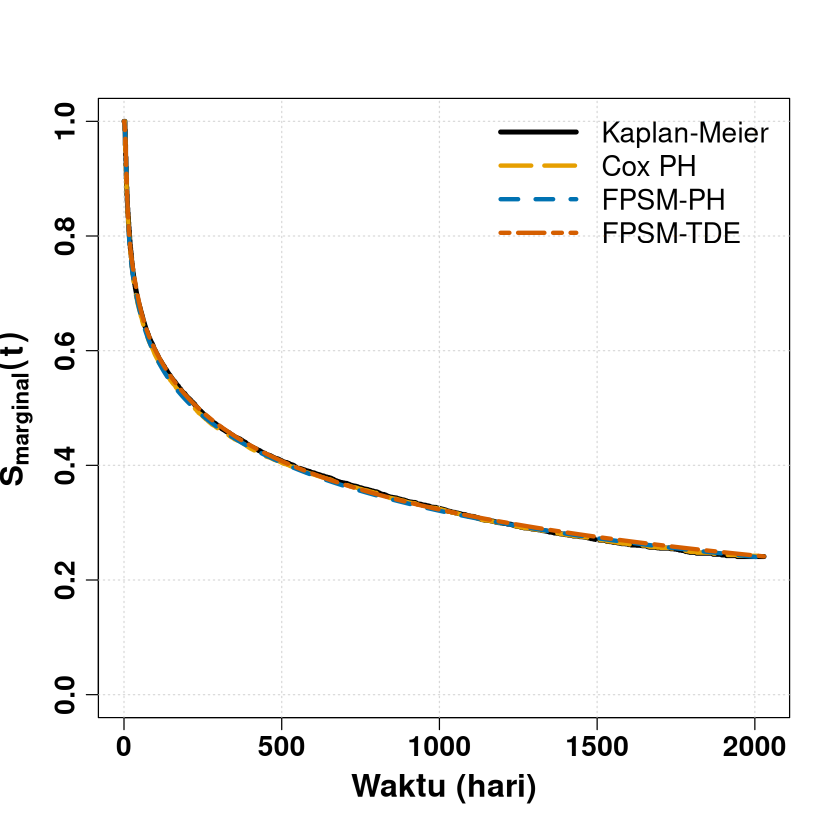

In [15]:
# Overall
plot_overlay_overall(
  data       = data,
  cox_model  = cox_model,
  fpsm_model = fpsm_5,
  fpsm_tde   = fpsm_time,
  add_title  = FALSE
)

In [42]:
png("marginal_dzclass_2.png", width = 3200, height = 3200, res = 300)

par(mfrow = c(2, 2), mar = c(5, 5, 4, 2))

plot_overlay_subgroup(data, cox_model, fpsm_5, fpsm_time,
                      var       = "dzclass_Cancer",
                      var_label = "Kanker",
                      group_val = 1,
                      add_title = FALSE,
                      show_legend = TRUE)

plot_overlay_subgroup(data, cox_model, fpsm_5, fpsm_time,
                      var       = "dzclass_COPD_CHF_Cirrhosis",
                      var_label = "COPD/CHF/Sirosis",
                      group_val = 1,
                      add_title = FALSE,
                      show_legend = FALSE)

plot_overlay_subgroup(data, cox_model, fpsm_5, fpsm_time,
                      var       = "dzclass_Coma",
                      var_label = "Koma",
                      group_val = 1,
                      add_title = FALSE,
                      show_legend = FALSE)

plot_overlay_subgroup(
  data, cox_model, fpsm_5, fpsm_time,
  var          = "dzclass_Cancer",
  var_label    = "ARF/MOSF",
  group_val    = 0,
  extra_filter = data$dzclass_COPD_CHF_Cirrhosis == 0 & 
                 data$dzclass_Coma == 0,
  add_title    = FALSE,
  show_legend  = FALSE
)

dev.off()

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local

pdf 
  2

In [43]:
png("marginal_cancer.png", width = 4800, height = 3200, res = 300)

layout(matrix(c(1, 2, 3, 3), nrow = 2, byrow = TRUE),
       widths = c(1, 1))

par(mar = c(5, 5, 4, 2))

plot_overlay_subgroup(data, cox_model, fpsm_5, fpsm_time,
                      var         = "ca_metastatic",
                      var_label   = "Metastatik",
                      group_val   = 1,
                      add_title   = FALSE,
                      show_legend = TRUE)

plot_overlay_subgroup(data, cox_model, fpsm_5, fpsm_time,
                      var         = "ca_yes",
                      var_label   = "Nonmetastatik",
                      group_val   = 1,
                      add_title   = FALSE,
                      show_legend = FALSE)

plot_overlay_subgroup(data, cox_model, fpsm_5, fpsm_time,
                      var         = "ca_yes",
                      var_label   = "Tidak Kanker",
                      extra_filter = data$ca_metastatic == 0,
                      group_val   = 0,
                      add_title   = FALSE,
                      show_legend = FALSE)

dev.off()

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=5).”
Warning message in local

pdf 
  2

Cutoff scoma = 0.0000

Grup 0 (<= cutoff) : n = 6400

Grup 1 (>  cutoff) : n = 2703

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, expose

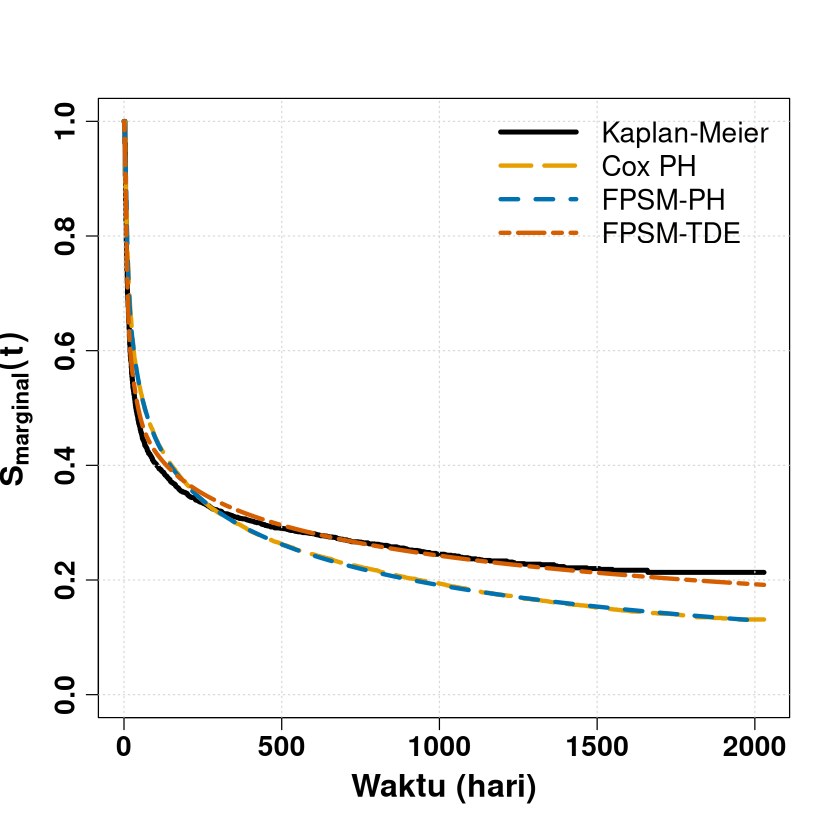

In [37]:
par(mfrow = c(1, 1))
plot_overlay_cutoff(
  data         = data,
  cont_var     = "scoma",
  cutoff       = 0,
  which_group  = "hi",          # "lo", "hi", atau "both"
  var_label_lo = "Skor Koma \u2264 0",
  cox_model    = cox_model,
  fpsm_model   = fpsm_5,
  fpsm_tde     = fpsm_time,
  show_legend  = TRUE,
  add_title    = FALSE
)

# Aplikasi Model

### Pasien Kanker vs Pasien Koma

In [29]:
# Membuat profil pasien standar (semua variabel lain dianggap 0 atau rata-rata)
bd <- data.frame(
  scoma = median(data$scoma), 
  age = median(data$age), 
  hday = median(data$hday), 
  meanbp = median(data$meanbp), 
  wblc = median(data$wblc),
  hrt = median(data$hrt), 
  resp = median(data$resp), 
  temp = median(data$temp), 
  pafi = median(data$pafi), 
  alb = median(data$alb),
  bili = median(data$bili), 
  crea = median(data$crea), 
  sod = median(data$sod), 
  ph = median(data$ph),
  dzclass_COPD_CHF_Cirrhosis = 0, 
  dzclass_Cancer = 0,
  dzclass_Coma = 0, 
  ca_metastatic = 0, 
  ca_yes = 0,
  sex_female = 0
)

In [30]:
plot_hr_tde <- function(hr_df, show_legend = TRUE) {
  
  # --- Warna & Style (konsisten dengan overlay) ---
  col_line   <- "#D55E00"
  col_ribbon <- "#D55E00"
  col_hline  <- "black"
  
  lty_line  <- 6
  lty_hline <- 5
  lwd_line  <- 3.5
  lwd_hline <- 2.5
  
  # --- Data ---
  lower <- hr_df$lower
  upper <- hr_df$upper
  est   <- hr_df$Estimate
  t     <- hr_df$t_key
  
  # --- Plot dasar ---
  par(mgp = c(2.5, 0.8, 0))
  
  plot(t, est,
       type     = "n",
       xlab     = "Waktu (hari)",
       ylab = expression(bold(hat(HR)(t))),
       ylim     = c(min(lower, na.rm = TRUE) * 0.95,
                    max(upper, na.rm = TRUE) * 1.05),
       cex.lab  = 1.6,
       cex.axis = 1.4,
       font.lab  = 2,
       font.axis = 2)
  
  # Grid background
  grid(lty = 3, col = "gray85")
  
  # Ribbon CI
  polygon(c(t, rev(t)),
          c(upper, rev(lower)),
          col    = adjustcolor(col_ribbon, alpha.f = 0.25),
          border = NA)
  
  # Garis HR(t)
  lines(t, est,
        col = col_line,
        lwd = lwd_line,
        lty = lty_line)
  
  # Garis HR = 1
  abline(h   = 1,
         col = col_hline,
         lwd = lwd_hline,
         lty = lty_hline)
  
  # Legend
  if (show_legend) {
    legend("topright",
           legend  = c("HR(t)", "95% CI", "HR = 1"),
           col     = c(col_line,
                       adjustcolor(col_ribbon, alpha.f = 0.25),
                       col_hline),
           lty     = c(lty_line, 1, lty_hline),
           lwd     = c(lwd_line, 8, lwd_hline),
           bty     = "n",
           cex     = 1.4,
           seg.len = 3)
  }
  
  invisible(NULL)
}

In [31]:
summarise_hr <- function(hr_df) {
  
  min_pt  <- hr_df[which.min(hr_df$Estimate), ]
  max_pt  <- hr_df[which.max(hr_df$Estimate), ]
  
  nonsig  <- hr_df %>%
    filter(!(lower > 1 | upper < 1)) %>%
    summarise(
      t_min = min(t_key),
      t_max = max(t_key),
      n     = n()
    )
  
  cat("=== Ringkasan HR(t) ===\n\n")
  
  cat(sprintf("HR Minimum : %.4f  (t = %d)\n",
              min_pt$Estimate, min_pt$t_key))
  cat(sprintf("  95%% CI   : [%.4f, %.4f]\n\n",
              min_pt$lower, min_pt$upper))
  
  cat(sprintf("HR Maksimum: %.4f  (t = %d)\n",
              max_pt$Estimate, max_pt$t_key))
  cat(sprintf("  95%% CI   : [%.4f, %.4f]\n\n",
              max_pt$lower, max_pt$upper))
  
  if (nrow(nonsig) == 0 || nonsig$n == 0) {
    cat("Signifikansi: Signifikan sepanjang waktu pengamatan\n")
  } else {
    cat(sprintf("Tidak signifikan: t = %d hingga t = %d (%d titik waktu)\n",
                nonsig$t_min, nonsig$t_max, nonsig$n))
  }
}

In [32]:
plot_surv_overlay <- function(surv1, surv2,
                               label1 = "Cancer",
                               label2 = "Coma",
                               show_legend = TRUE) {
  
  # --- Warna & Style ---
  col1        <- "#FF746C"   # oranye
  col2        <- "#5BAFD6"   # biru muda
  col_hline   <- "black"
  
  lty_line  <- 6
  lty_hline <- 5
  lwd_line  <- 3.5
  lwd_hline <- 2.5
  
  # --- Data ---
  t      <- surv1$t_key   # asumsi t_key sama (sudah di-snap ke t_diskrit)
  
  est1   <- surv1$Estimate
  lower1 <- surv1$lower
  upper1 <- surv1$upper
  
  est2   <- surv2$Estimate
  lower2 <- surv2$lower
  upper2 <- surv2$upper
  
  # --- Batas y ---
  ymin <- min(lower1, lower2, na.rm = TRUE) * 0.95
  ymax <- max(upper1, upper2, na.rm = TRUE) * 1.05
  ymax <- min(ymax, 1.05)   # S(t) tidak melebihi 1
  
  # --- Plot dasar ---
  par(mgp = c(2.5, 0.8, 0))
  
  plot(t, est1,
       type     = "n",
       xlab     = "Waktu (hari)",
       ylab     = expression(bold(hat(S)(t))),
       ylim     = c(ymin, ymax),
       cex.lab  = 1.2,
       cex.axis = 1.4,
       font.lab  = 2,
       font.axis = 2)
  
  # Grid background
  grid(lty = 3, col = "gray85")
  
  # --- Ribbon CI: surv1 ---
  polygon(c(t, rev(t)),
          c(upper1, rev(lower1)),
          col    = adjustcolor(col1, alpha.f = 0.20),
          border = NA)
  
  # --- Ribbon CI: surv2 ---
  polygon(c(t, rev(t)),
          c(upper2, rev(lower2)),
          col    = adjustcolor(col2, alpha.f = 0.20),
          border = NA)
  
  # --- Garis S(t) ---
  lines(t, est1,
        col = col1,
        lwd = lwd_line,
        lty = lty_line)
  
  lines(t, est2,
        col = col2,
        lwd = lwd_line,
        lty = lty_line)

  # --- Legend ---
  if (show_legend) {
    legend("topright",
           legend  = c(
             paste0(label1, " — S(t)"),
             paste0(label1, " — 95% CI"),
             paste0(label2, " — S(t)"),
             paste0(label2, " — 95% CI")
           ),
           col     = c(col1,
                       adjustcolor(col1, alpha.f = 0.20),
                       col2,
                       adjustcolor(col2, alpha.f = 0.20)),
           lty     = c(lty_line, 1, lty_line, 1),
           lwd     = c(lwd_line, 8, lwd_line, 8),
           bty     = "n",
           cex     = 1.3,
           seg.len = 3)
  }
  
  invisible(NULL)
}

In [33]:
predict_cox <- function(cox_model, newdata, t_diskrit) {
  
  sf     <- survfit(cox_model, newdata = newdata)
  sf_sum <- summary(sf, times = t_diskrit, extend = TRUE)
  
  data.frame(
    Estimate = sf_sum$surv,
    lower    = sf_sum$lower,
    upper    = sf_sum$upper,
    t_key    = t_diskrit
  )
}

In [52]:
# Cancer vs Coma

bd_coma <- bd
bd_coma$dzclass_Coma <- 1

bd_cancer <- bd
bd_cancer$dzclass_Cancer <- 1

hr_cancer_coma <- predict(fpsm_time,
                       newdata  = bd_coma,
                       exposed = function(data) {
                         data$dzclass_Coma <- 0
                         data$dzclass_Cancer <- 1
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
t_diskrit <- 3:1944
hr_cancer_coma <- hr_cancer_coma %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

In [78]:
# Cancer vs Coma

bd_coma <- bd
bd_coma$dzclass_Coma <- 1

bd_cancer <- bd
bd_cancer$dzclass_Cancer <- 1

hr_cancer_coma_2 <- predict(fpsm_5,
                       newdata  = bd_coma,
                       exposed = function(data) {
                         data$dzclass_Coma <- 0
                         data$dzclass_Cancer <- 1
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
t_diskrit <- 3:1944
hr_cancer_coma_2 <- hr_cancer_coma_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

In [35]:
surv_cancer <- predict(fpsm_time,
                       newdata  = bd_cancer,
                       type = "surv", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
surv_cancer <- surv_cancer %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

surv_coma <- predict(fpsm_time,
                       newdata  = bd_coma,
                       type = "surv", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
surv_coma <- surv_coma %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)


In [91]:
colnames(data)

[1] "age"                        "hday"                      
 [3] "scoma"                      "meanbp"                    
 [5] "wblc"                       "hrt"                       
 [7] "resp"                       "temp"                      
 [9] "pafi"                       "alb"                       
[11] "bili"                       "crea"                      
[13] "sod"                        "ph"                        
[15] "d.time"                     "death"                     
[17] "dzclass_COPD_CHF_Cirrhosis" "dzclass_Cancer"            
[19] "dzclass_Coma"               "ca_metastatic"             
[21] "ca_yes"                     "sex_female"

In [36]:
surv_cancer_2 <- predict(fpsm_5,
                       newdata  = bd_cancer,
                       type = "surv", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
surv_cancer_2 <- surv_cancer_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

surv_coma_2 <- predict(fpsm_5,
                       newdata  = bd_coma,
                       type = "surv", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
surv_coma_2 <- surv_coma_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)


In [48]:
summarise_hr(hr_cancer_coma)

=== Ringkasan HR(t) ===

HR Minimum : 0.2626  (t = 4)
  95% CI   : [0.1931, 0.3573]

HR Maksimum: 1.5433  (t = 226)
  95% CI   : [1.2826, 1.8570]

Tidak signifikan: t = 50 hingga t = 76 (27 titik waktu)


In [49]:
# event_times <- fit_overall$time[fit_overall$n.event > 0]

# # Buat tabel gap antar event
# gaps <- data.frame(
#   dari = head(event_times, -1),
#   sampai = tail(event_times, -1),
#   gap = diff(event_times)
# )

# # Urutkan dari gap terbesar
# gaps[order(-gaps$gap), ]

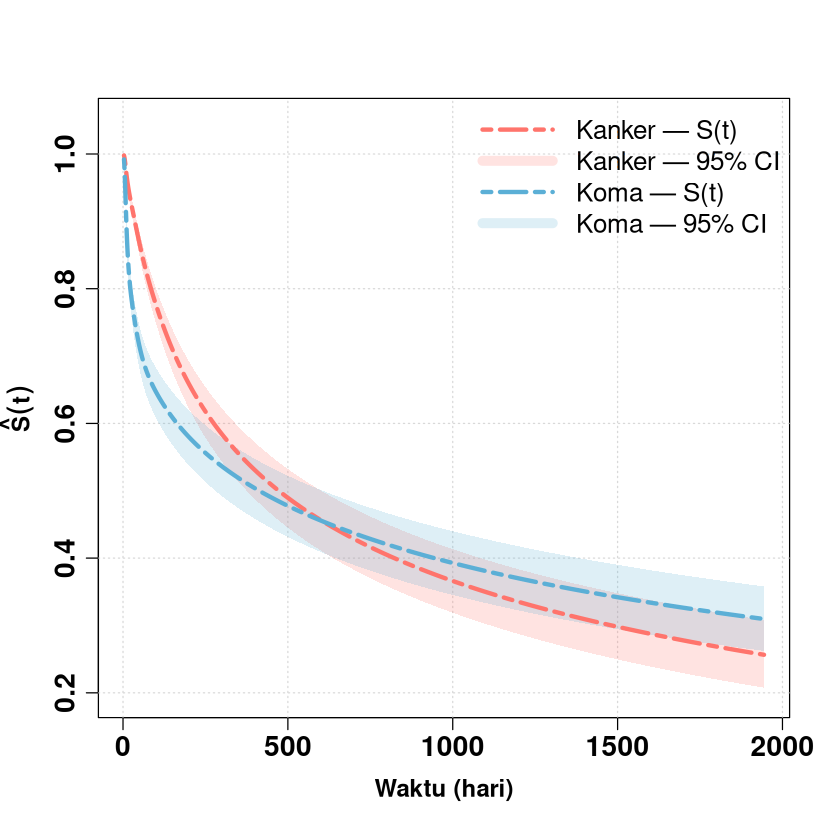

In [80]:
plot_surv_overlay((surv_cancer), (surv_coma),
                  label1 = "Kanker",
                  label2 = "Koma")

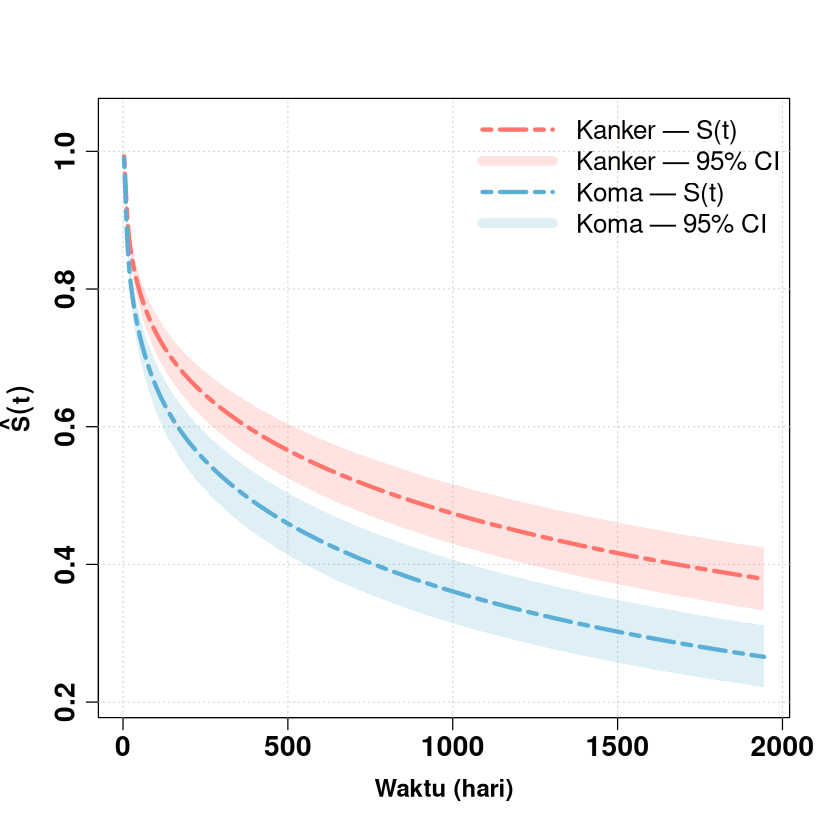

In [81]:
plot_surv_overlay((surv_cancer_2), (surv_coma_2),
                  label1 = "Kanker",
                  label2 = "Koma")

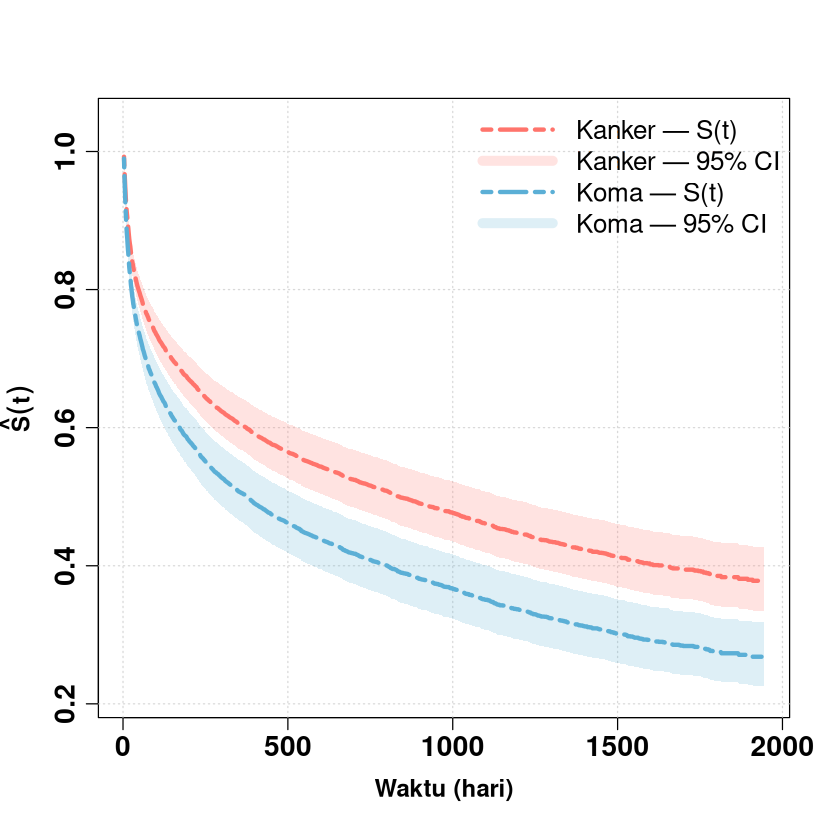

In [37]:
surv_cancer_cox = predict_cox(cox_model, newdata = bd_cancer, t_diskrit = t_diskrit)
surv_coma_cox = predict_cox(cox_model, newdata = bd_coma, t_diskrit = t_diskrit)
plot_surv_overlay(surv_cancer_cox, surv_coma_cox,
                  label1 = "Kanker",
                  label2 = "Koma")

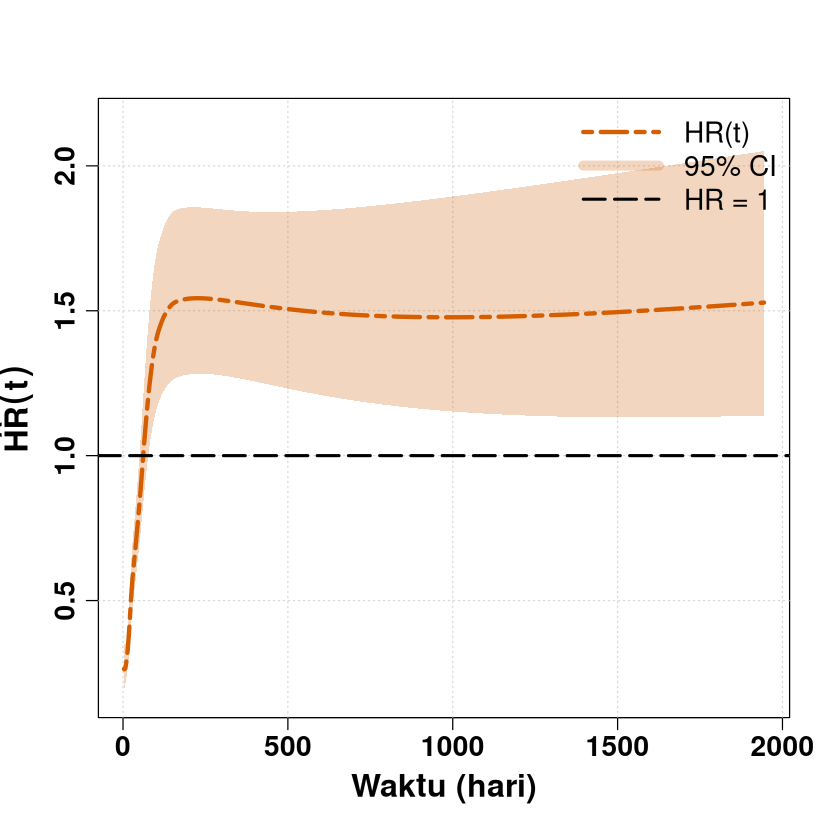

In [47]:
plot_hr_tde(hr_cancer_coma)

In [80]:
summarise_hr(hr_cancer_coma_2)

Warning message:
“There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `t_min = min(t_key)`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


=== Ringkasan HR(t) ===

HR Minimum : 0.7324  (t = 351)
  95% CI   : [0.6214, 0.8631]

HR Maksimum: 0.7324  (t = 86)
  95% CI   : [0.6214, 0.8631]

Signifikansi: Signifikan sepanjang waktu pengamatan


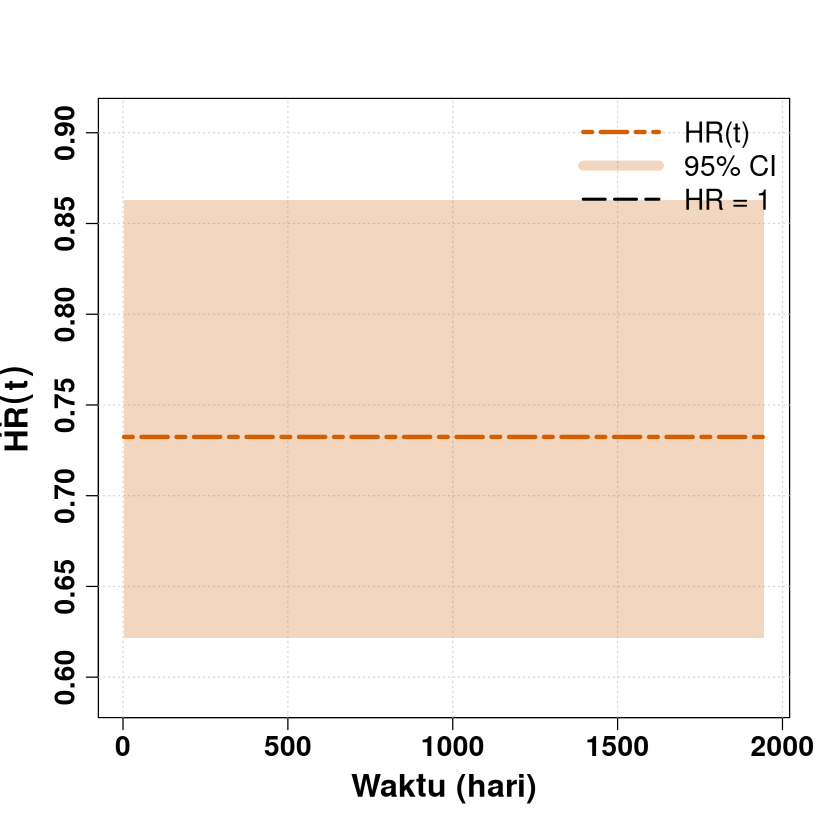

In [79]:
plot_hr_tde(hr_cancer_coma_2)

In [82]:
# ============================================================
# PREDICT HR untuk COX PH
# Cancer vs Coma (Reference)
# ============================================================

# Setup reference & exposed
bd_ref <- bd  # Coma (reference)
bd_ref$dzclass_Coma <- 1
bd_ref$dzclass_Cancer <- 0
bd_ref$dzclass_COPD_CHF_Cirrhosis <- 0

bd_exposed <- bd
bd_exposed$dzclass_Coma <- 0
bd_exposed$dzclass_Cancer <- 1
bd_exposed$dzclass_COPD_CHF_Cirrhosis <- 0

# Dari coefficient Cox
# HR(Cancer vs Coma) = exp(coef_Cancer - coef_Coma)
coef_cancer <- cox_model$coefficients["dzclass_Cancer"]
coef_coma <- cox_model$coefficients["dzclass_Coma"]

hr_cox_est <- exp(coef_cancer - coef_coma)

# Untuk CI, hitung dari variance-covariance matrix
vcov_matrix <- vcov(cox_model)
se_diff <- sqrt(vcov_matrix["dzclass_Cancer", "dzclass_Cancer"] + 
                vcov_matrix["dzclass_Coma", "dzclass_Coma"] - 
                2 * vcov_matrix["dzclass_Cancer", "dzclass_Coma"])

hr_cox_ci_lower <- exp((coef_cancer - coef_coma) - 1.96 * se_diff)
hr_cox_ci_upper <- exp((coef_cancer - coef_coma) + 1.96 * se_diff)

cat("=== HR Cox PH (Cancer vs Coma) ===\n")
cat(sprintf("HR Estimate: %.4f\n", hr_cox_est))
cat(sprintf("95%% CI     : [%.4f, %.4f]\n\n", hr_cox_ci_lower, hr_cox_ci_upper))

# Create data frame (konsisten format dengan FPSM-TDE)
t_diskrit <- 3:1944

hr_cox_df <- data.frame(
  t_key = t_diskrit,
  Estimate = rep(hr_cox_est, length(t_diskrit)),
  lower = rep(hr_cox_ci_lower, length(t_diskrit)),
  upper = rep(hr_cox_ci_upper, length(t_diskrit))
)

=== HR Cox PH (Cancer vs Coma) ===
HR Estimate: 0.7388
95% CI     : [0.6268, 0.8708]



In [56]:
compute_conditional_rmst <- function(model, tau, newdata, 
                                      time_var = "d.time",
                                      n_times = 30) {
  times <- seq(0, tau, length.out = n_times)
  
  surv_curve <- sapply(times, function(t) {
    data_temp <- newdata
    data_temp[[time_var]] <- t
    pred <- tryCatch(
      predict(model, newdata = data_temp, type = "surv"),
      error = function(e) NA
    )
    as.numeric(pred)
  })
  
  pracma::trapz(times, surv_curve)
}

compute_conditional_rmst_cox <- function(cox_model, tau, newdata,
                                          n_times = 1000) {
  times <- seq(0, tau, length.out = n_times)
  
  # survfit untuk newdata
  sf <- survfit(cox_model, newdata = newdata)
  
  # Interpolasi S(t) di times yang kita mau
  surv_curve <- stepfun(sf$time, c(1, sf$surv))(times)
  
  pracma::trapz(times, surv_curve)
}

In [57]:
# Hitung RMST kondisional untuk bd_data
rmst_cond_cox  <- compute_conditional_rmst_cox(cox_model, tau = 30, newdata = bd_coma)
rmst_cond_fpsm <- compute_conditional_rmst(fpsm_5,    tau = 30, newdata = bd_coma)
rmst_cond_tde  <- compute_conditional_rmst(fpsm_time, tau = 30, newdata = bd_coma)

# Tampilkan
data.frame(
  Model = c("Cox PH", "FPSM-PH", "FPSM-TDE"),
  RMST  = c(rmst_cond_cox, rmst_cond_fpsm, rmst_cond_tde)
)

Model,RMST
<chr>,<dbl>
Cox PH,26.29335
FPSM-PH,26.24184
FPSM-TDE,26.01471


In [76]:
# Hitung RMST kondisional untuk bd_data
rmst_cox_cancer_90    <- compute_conditional_rmst_cox(cox_model, tau = 180,   newdata = bd_cancer)
rmst_fpsm_cancer_90   <- compute_conditional_rmst(fpsm_5,        tau = 180,   newdata = bd_cancer)
rmst_tde_cancer_90    <- compute_conditional_rmst(fpsm_time,     tau = 180,   newdata = bd_cancer)

rmst_cox_cancer_1944  <- compute_conditional_rmst_cox(cox_model, 1944, newdata = bd_cancer)
rmst_fpsm_cancer_1944 <- compute_conditional_rmst(fpsm_5,        1944, newdata = bd_cancer)
rmst_tde_cancer_1944  <- compute_conditional_rmst(fpsm_time,     1944, newdata = bd_cancer)

rmst_cox_coma_90      <- compute_conditional_rmst_cox(cox_model, tau = 180,   newdata = bd_coma)
rmst_fpsm_coma_90     <- compute_conditional_rmst(fpsm_5,        tau = 180,   newdata = bd_coma)
rmst_tde_coma_90      <- compute_conditional_rmst(fpsm_time,     tau = 180,   newdata = bd_coma)

rmst_cox_coma_1944    <- compute_conditional_rmst_cox(cox_model, 1944, newdata = bd_coma)  # typo diperbaiki
rmst_fpsm_coma_1944   <- compute_conditional_rmst(fpsm_5,        1944, newdata = bd_coma)
rmst_tde_coma_1944    <- compute_conditional_rmst(fpsm_time,     1944, newdata = bd_coma)

# Tabel ringkasan
data.frame(
  Model    = c("Cox PH", "FPSM-PH", "FPSM-TDE"),
  
  Cancer_90    = c(rmst_cox_cancer_90,   rmst_fpsm_cancer_90,   rmst_tde_cancer_90),
  Coma_90      = c(rmst_cox_coma_90,     rmst_fpsm_coma_90,     rmst_tde_coma_90),
  Diff_90      = c(rmst_cox_cancer_90   - rmst_cox_coma_90,
                   rmst_fpsm_cancer_90  - rmst_fpsm_coma_90,
                   rmst_tde_cancer_90   - rmst_tde_coma_90),
  
  Cancer_1944  = c(rmst_cox_cancer_1944, rmst_fpsm_cancer_1944, rmst_tde_cancer_1944),
  Coma_1944    = c(rmst_cox_coma_1944,   rmst_fpsm_coma_1944,   rmst_tde_coma_1944),
  Diff_1944    = c(rmst_cox_cancer_1944  - rmst_cox_coma_1944,
                   rmst_fpsm_cancer_1944 - rmst_fpsm_coma_1944,
                   rmst_tde_cancer_1944  - rmst_tde_coma_1944)
)

Model,Cancer_90,Coma_90,Diff_90,Cancer_1944,Coma_1944,Diff_1944
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Cox PH,138.1784,126.1363,12.04214,989.0070,787.9279,201.07907
FPSM-PH,138.1604,125.7336,12.42677,993.6499,787.6260,206.02389
FPSM-TDE,145.2883,123.8900,21.39829,825.5640,838.9256,-13.36163


### RMST

#### RMST Kaplan-Meier

In [27]:
# Overall
print(fit_overall, rmean = 1944)

Call: survfit(formula = surv_object ~ 1, data = data)

        n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 9103   6199    704      8.82    233     217     252
    * restricted mean with upper limit =  1944 


In [ ]:
# Berdasarkan kelas referensi
data_arf <- data[
  data$dzclass_Cancer == 0 &
  data$dzclass_Coma == 0 &
  data$dzclass_COPD_CHF_Cirrhosis == 0, ]

km_arf <- survfit(Surv(d.time, death) ~ 1, data = data_arf)
print(km_arf, rmean = 1944)

Call: survfit(formula = Surv(d.time, death) ~ 1, data = data_arf)

        n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 4225   2721    748      13.6    187     154     226
    * restricted mean with upper limit =  1944 


In [ ]:
# Berdasarkan kelas kanker
data_cancer <- data[
  data$dzclass_Cancer == 1 &
  data$dzclass_Coma == 0 &
  data$dzclass_COPD_CHF_Cirrhosis == 0, ]

km_cancer <- survfit(Surv(d.time, death) ~ 1, data = data_cancer)
print(km_cancer, rmean = 1944)

Call: survfit(formula = Surv(d.time, death) ~ 1, data = data_cancer)

        n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 1420   1260    359      14.6    140     128     155
    * restricted mean with upper limit =  1944 


In [50]:
# Berdasarkan kelas copd
data_copd <- data[
  data$dzclass_Cancer == 0 &
  data$dzclass_Coma == 0 &
  data$dzclass_COPD_CHF_Cirrhosis == 1, ]

km_copd <- survfit(Surv(d.time, death) ~ 1, data = data_copd)
print(km_copd, rmean = 1944)

Call: survfit(formula = Surv(d.time, death) ~ 1, data = data_copd)

        n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 2862   1734    885      15.8    634     570     680
    * restricted mean with upper limit =  1944 


In [51]:
# Berdasarkan kelas koma
data_coma <- data[
  data$dzclass_Cancer == 0 &
  data$dzclass_Coma == 1 &
  data$dzclass_COPD_CHF_Cirrhosis == 0, ]

km_coma <- survfit(Surv(d.time, death) ~ 1, data = data_coma)
print(km_coma, rmean = 1944)

Call: survfit(formula = Surv(d.time, death) ~ 1, data = data_coma)

       n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 596    484    393      30.6     12      10      15
    * restricted mean with upper limit =  1944 


In [52]:
# Berdasarkan variabel ca: metastatik
data_meta <- data[
  data$ca_metastatic == 1 &
  data$ca_yes == 0, ]

km_meta <- survfit(Surv(d.time, death) ~ 1, data = data_meta)
print(km_meta, rmean = 1944)

Call: survfit(formula = Surv(d.time, death) ~ 1, data = data_meta)

        n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 1858   1659    330      12.6    112     101     126
    * restricted mean with upper limit =  1944 


In [62]:
# Berdasarkan variabel ca: nonmetastatik
data_nonmeta <- data[
  data$ca_metastatic == 0 &
  data$ca_yes == 1, ]

km_nonmeta <- survfit(Surv(d.time, death) ~ 1, data = data_nonmeta)
print(km_nonmeta, rmean = 1944)

Call: survfit(formula = Surv(d.time, death) ~ 1, data = data_nonmeta)

        n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 1252    952    533      21.9   92.5      70     114
    * restricted mean with upper limit =  1944 


In [54]:
# Berdasarkan variabel ca: tidak kanker
data_nocancer <- data[
  data$ca_metastatic == 0 &
  data$ca_yes == 0, ]

km_nocancer <- survfit(Surv(d.time, death) ~ 1, data = data_nocancer)
print(km_nocancer, rmean = 1944)

Call: survfit(formula = Surv(d.time, death) ~ 1, data = data_nocancer)

        n events rmean* se(rmean) median 0.95LCL 0.95UCL
[1,] 5993   3588    857      11.4    477     423     543
    * restricted mean with upper limit =  1944 


#### RMST Model Lain

In [33]:
# Overall: semua baris data
compute_marginal_rmst_overall <- function(model, tau , data, 
                                          time_var = "d.time", 
                                          n_times = 1000) {
  times <- seq(0, tau, length.out = n_times)
  
  marginal_surv <- sapply(times, function(t) {
    data_temp <- data
    data_temp[[time_var]] <- t
    preds <- tryCatch(
      predict(model, newdata = data_temp, type = "surv"),
      error = function(e) rep(NA, nrow(data))
    )
    mean(as.numeric(preds), na.rm = TRUE)
  })
  
  pracma::trapz(times, marginal_surv)
}

# Hitung
rmst_overall_cox  <- compute_marginal_rmst_overall(cox_model, tau = 1944, data)
rmst_overall_fpsm <- compute_marginal_rmst_overall(fpsm_5,    tau = 1944, data)
rmst_overall_tde  <- compute_marginal_rmst_overall(fpsm_time, tau = 1944, data)

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local

In [37]:
rmst_overall_cox
rmst_overall_fpsm
rmst_overall_tde

[1] 700.9176

[1] 700.8648

[1] 707.3188

In [23]:
compute_marginal_rmst <- function(
    data_sub,
    fpsm_model,
    tau,            # horizon waktu, misal 180 hari
    n_times = 1000,
    time_var = "d.time"
) {
  times <- seq(0, tau, length.out = n_times)

  marginal_surv <- sapply(times, function(t) {
    data_temp <- data_sub
    data_temp[[time_var]] <- t
    preds <- tryCatch(
      predict(fpsm_model, newdata = data_temp, type = "surv"),
      error = function(e) rep(NA, nrow(data_sub))
    )
    mean(as.numeric(preds), na.rm = TRUE)
  })

  # Integrasi numerik dengan trapezoid rule
  rmst <- pracma::trapz(times, marginal_surv)
  return(rmst)
}

In [39]:
tau <- 1944  # horizon: misal 180 hari

# Subgrup Cancer
data_cancer <- data[data$dzclass_Cancer == 1, ]

# Subgrup ARF (referensi)
data_arf <- data[
  data$dzclass_Cancer == 0 &
  data$dzclass_COPD_CHF_Cirrhosis == 0 &
  data$dzclass_Coma == 0, ]

# Subgrup COPD/CHF/Cirrhosis
data_copd <- data[data$dzclass_COPD_CHF_Cirrhosis == 1, ]

# Subgrup Coma (referensi)
data_coma <- data[data$dzclass_Coma == 1, ]

# Hitung RMST per model per subgrup
rmst_cancer_cox    <- compute_marginal_rmst(data_cancer, cox_model,  tau)
rmst_cancer_fpsm   <- compute_marginal_rmst(data_cancer, fpsm_5,     tau)
rmst_cancer_tde    <- compute_marginal_rmst(data_cancer, fpsm_time,  tau)

rmst_arf_cox       <- compute_marginal_rmst(data_arf,    cox_model,  tau)
rmst_arf_fpsm      <- compute_marginal_rmst(data_arf,    fpsm_5,     tau)
rmst_arf_tde       <- compute_marginal_rmst(data_arf,    fpsm_time,  tau)

rmst_copd_cox    <- compute_marginal_rmst(data_copd, cox_model,  tau)
rmst_copd_fpsm   <- compute_marginal_rmst(data_copd, fpsm_5,     tau)
rmst_copd_tde    <- compute_marginal_rmst(data_copd, fpsm_time,  tau)

rmst_coma_cox       <- compute_marginal_rmst(data_coma,    cox_model,  tau)
rmst_coma_fpsm      <- compute_marginal_rmst(data_coma,    fpsm_5,     tau)
rmst_coma_tde       <- compute_marginal_rmst(data_coma,    fpsm_time,  tau)

# Ringkasan
results <- data.frame(
  Subgrup = c("Cancer", "ARF", "COPD", "Coma"),
  Cox_PH  = c(rmst_cancer_cox,  rmst_arf_cox, rmst_copd_cox, rmst_coma_cox),
  FPSM_PH = c(rmst_cancer_fpsm, rmst_arf_fpsm, rmst_copd_fpsm, rmst_coma_fpsm),
  FPSM_TDE= c(rmst_cancer_tde,  rmst_arf_tde, rmst_copd_tde, rmst_coma_tde)
)

# # Selisih (RMST difference)
# results$Diff_TDE_vs_Cox  <- results$FPSM_TDE - results$Cox_PH
# results$Diff_TDE_vs_FPSM <- results$FPSM_TDE - results$FPSM_PH

# print(results)

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local

In [43]:
results

Subgrup,Cox_PH,FPSM_PH,FPSM_TDE
<chr>,<dbl>,<dbl>,<dbl>
Cancer,437.4246,437.4195,358.5659
ARF,712.5013,712.4664,753.8933
COPD,905.3957,905.8644,882.8243
Coma,264.6799,261.8834,365.2978


In [60]:
tau <- 1944  # horizon: misal 180 hari

# Subgrup Metastatik
data_meta <- data[data$ca_metastatic == 1,]

# Subgrup Nonmetastatik
data_nonmeta <- data[data$ca_yes == 1, ]

# Subgrup Tidak Kanker
data_nocancer <- data[
  data$ca_metastatic == 0 &
  data$ca_yes == 0, ]


# Hitung RMST per model per subgrup
rmst_meta_cox    <- compute_marginal_rmst(data_meta, cox_model,  tau)
rmst_meta_fpsm   <- compute_marginal_rmst(data_meta, fpsm_5,     tau)
rmst_meta_tde    <- compute_marginal_rmst(data_meta, fpsm_time,  tau)

rmst_nonmeta_cox       <- compute_marginal_rmst(data_nonmeta,    cox_model,  tau)
rmst_nonmeta_fpsm      <- compute_marginal_rmst(data_nonmeta,    fpsm_5,     tau)
rmst_nonmeta_tde       <- compute_marginal_rmst(data_nonmeta,    fpsm_time,  tau)

rmst_nocancer_cox    <- compute_marginal_rmst(data_nocancer, cox_model,  tau)
rmst_nocancer_fpsm   <- compute_marginal_rmst(data_nocancer, fpsm_5,     tau)
rmst_nocancer_tde    <- compute_marginal_rmst(data_nocancer, fpsm_time,  tau)

# Ringkasan
results <- data.frame(
  Subgrup = c("Cancer", "Non-Metastatik", "Non-Kanker"),
  Cox_PH  = c(rmst_meta_cox,  rmst_nonmeta_cox, rmst_nocancer_cox),
  FPSM_PH = c(rmst_meta_fpsm, rmst_nonmeta_fpsm, rmst_nocancer_fpsm),
  FPSM_TDE= c(rmst_meta_tde,  rmst_nonmeta_tde, rmst_nocancer_tde)
)

# # Selisih (RMST difference)
# results$Diff_TDE_vs_Cox  <- results$FPSM_TDE - results$Cox_PH
# results$Diff_TDE_vs_FPSM <- results$FPSM_TDE - results$FPSM_PH

# print(results)

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=3).”
Warning message in local

In [61]:
results

Subgrup,Cox_PH,FPSM_PH,FPSM_TDE
<chr>,<dbl>,<dbl>,<dbl>
Cancer,402.1979,401.9459,349.2566
Non-Metastatik,524.5218,524.0419,558.2869
Non-Kanker,830.3800,830.4784,849.4626


## t-AUC

In [22]:
# ============================================================
# TRAIN-TEST SPLIT STRATIFIED BY EVENT STATUS
# ============================================================

set.seed(123)

# Stratified split berdasarkan data$death
idx_event     <- which(data$death == 1)
idx_nonevent  <- which(data$death == 0)

train_event    <- sample(idx_event,    size = floor(0.7 * length(idx_event)))
train_nonevent <- sample(idx_nonevent, size = floor(0.7 * length(idx_nonevent)))

train_idx <- c(train_event, train_nonevent)
test_idx  <- setdiff(seq_len(nrow(data)), train_idx)

data_train <- data[train_idx, ]
data_test  <- data[test_idx,  ]

message(sprintf("Train: n = %d, events = %d (%.1f%%)",
                nrow(data_train), sum(data_train$death),
                100 * mean(data_train$death)))
message(sprintf("Test:  n = %d, events = %d (%.1f%%)",
                nrow(data_test),  sum(data_test$death),
                100 * mean(data_test$death)))

Train: n = 6371, events = 4339 (68.1%)

Test:  n = 2732, events = 1860 (68.1%)



In [ ]:
# ============================================================
# REFIT MODEL PADA TRAIN DATA
# ============================================================

# -- Cox PH (salin formula dari cox_model asli)
cox_train <- update(cox_model, data = data_train)

# -- FPSM-PH (salin formula dari fpsm_5 asli)
fpsm_train <- update(fpsm_5, data = data_train)

# -- FPSM-TDE (salin formula dari fpsm_time asli)
fpsm_tde_train <- update(fpsm_time, data = data_train)

In [25]:
# Fungsi Time-dependent AUC

evaluate_model_auc <- function(model_obj, model_type = c("fpsm", "cox"), data, target_times) {
  
  # Fungsi internal untuk hitung AUC per satu titik waktu
  get_auc_single <- function(t) {
    if (model_type == "fpsm") {
      # Prediksi F(t|X) = 1 - S(t|X) di FPSM untuk satu t spesifik
      data_temp <- data
      data_temp$d.time <- t
      marker <- 1 - as.numeric(predict(model_obj, newdata = data_temp, type = "surv"))
    } else {
      # Prediksi F(t|X) = 1 - S(t|X) di Cox untuk satu t spesifik
      fit_cox <- survfit(model_obj, newdata = data)
      marker <- 1 - as.numeric(summary(fit_cox, times = t)$surv)
    }
    
    # Hitung AUC untuk satu t tersebut
    res <- timeROC(T = data$d.time, 
                   delta = data$death, 
                   marker = marker, 
                   cause = 1, 
                   weighting = "marginal", 
                   times = t)
    return(res$AUC[2]) # Ambil nilai AUC pada t_1
  }
  
  # Jalankan untuk semua target_times yang diinput (bebas mau berapa pun)
  sapply(target_times, get_auc_single)
}


In [65]:
quantile(data$d.time[data$death == 1], 0.9)

90% 
634.2

In [28]:
# ============================================================
# HITUNG t-AUC: TRAIN DAN TEST
# ============================================================

eval_days <- c(7, 14, 30, 60, 90, 180, 365, 730, 1096, 1944)

eval_q <- as.numeric(quantile(data$d.time[data$death == 1], probs = c(0.25, 0.5, 0.75)))

# -- Train AUC (apparent pada train set)
auc_cox_train  <- evaluate_model_auc(cox_train,      "cox",  data_train, eval_days)
auc_fpsm_train <- evaluate_model_auc(fpsm_train,     "fpsm", data_train, eval_days)
auc_tde_train  <- evaluate_model_auc(fpsm_tde_train, "fpsm", data_train, eval_days)

# -- Test AUC (prediksi dari model train, dievaluasi di test set)
auc_cox_test  <- evaluate_model_auc(cox_train,      "cox",  data_test, eval_days)
auc_fpsm_test <- evaluate_model_auc(fpsm_train,     "fpsm", data_test, eval_days)
auc_tde_test  <- evaluate_model_auc(fpsm_tde_train, "fpsm", data_test, eval_days)

Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=12).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=44).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=44).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=51).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=60).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=63).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=65).”
Warning message i

In [27]:
# ============================================================
# TABEL HASIL dengan ROUNDING
# ============================================================

tabel_AUC_train <- data.frame(
  Waktu         = eval_days,
  AUC_Cox       = round(auc_cox_train, 2),
  AUC_FPSM_PH   = round(auc_fpsm_train, 2),
  AUC_FPSM_TDE  = round(auc_tde_train, 2)
)

tabel_AUC_test <- data.frame(
  Waktu         = eval_days,
  AUC_Cox       = round(auc_cox_test, 2),
  AUC_FPSM_PH   = round(auc_fpsm_test, 2),
  AUC_FPSM_TDE  = round(auc_tde_test, 2)
)

cat("\n=== t-AUC pada Train Set ===\n")
print(tabel_AUC_train)

cat("\n=== t-AUC pada Test Set ===\n")
print(tabel_AUC_test)


=== t-AUC pada Train Set ===


       Waktu AUC_Cox AUC_FPSM_PH AUC_FPSM_TDE
t=7        7    0.78        0.78         0.82
t=14      14    0.73        0.73         0.79
t=30      30    0.72        0.72         0.76
t=60      60    0.71        0.71         0.74
t=90      90    0.72        0.72         0.73
t=180    180    0.73        0.73         0.73
t=365    365    0.74        0.74         0.74
t=730    730    0.74        0.74         0.74
t=1096  1096    0.75        0.75         0.75
t=1944  1944    0.72        0.72         0.73

=== t-AUC pada Test Set ===
       Waktu AUC_Cox AUC_FPSM_PH AUC_FPSM_TDE
t=7        7    0.77        0.77         0.82
t=14      14    0.73        0.73         0.78
t=30      30    0.72        0.72         0.76
t=60      60    0.71        0.71         0.75
t=90      90    0.71        0.71         0.73
t=180    180    0.71        0.71         0.72
t=365    365    0.72        0.72         0.72
t=730    730    0.74        0.74         0.74
t=1096  1096    0.75        0.75         0.75
t=194

## BS and IBS

In [24]:
# ============================================================
# HITUNG SURVIVAL PROBABILITY MATRIX PADA TRAIN DATA
# (untuk evaluasi apparent / train BS)
# ============================================================

eval_bs <- c(3:max(data_train$d.time[data_train$death == 1]))

# -- Cox train
fit_cox_train     <- survfit(cox_train, newdata = data_train)
sp_cox_train      <- t(summary(fit_cox_train, times = eval_bs)$surv)

# -- FPSM-PH train
sp_fpsm_train <- sapply(eval_bs, function(t) {
  data_temp         <- data_train
  data_temp$d.time  <- t
  as.numeric(predict(fpsm_train, newdata = data_temp, type = "surv"))
})

# -- FPSM-TDE train
sp_tde_train <- sapply(eval_bs, function(t) {
  data_temp         <- data_train
  data_temp$d.time  <- t
  as.numeric(predict(fpsm_tde_train, newdata = data_temp, type = "surv"))
})

# Tambah S(0) = 1
eval_bs_pec_train       <- c(0, eval_bs)
sp_cox_train_pec        <- cbind(1, sp_cox_train)
sp_fpsm_train_pec       <- cbind(1, sp_fpsm_train)
sp_tde_train_pec        <- cbind(1, sp_tde_train)

# -- pec train
pec_train <- pec(
  object = list(
    "Cox"      = sp_cox_train_pec,
    "FPSM"     = sp_fpsm_train_pec,
    "FPSM_TDE" = sp_tde_train_pec
  ),
  formula    = Surv(d.time, death) ~ 1,
  data       = data_train,
  times      = eval_bs_pec_train,
  exact      = FALSE,
  cens.model = "marginal",
  ipcw.refit = TRUE
)

bs_train <- data.frame(
  Time      = pec_train$time,
  Reference = pec_train$AppErr$Reference,
  Cox       = pec_train$AppErr$Cox,
  FPSM      = pec_train$AppErr$FPSM,
  FPSM_Time = pec_train$AppErr$FPSM_TDE
) %>% filter(Time > 0)


# ============================================================
# HITUNG SURVIVAL PROBABILITY MATRIX PADA TEST DATA
# (model dari train, dievaluasi di test)
# ============================================================

eval_bs_test <- c(3:max(data_test$d.time[data_test$death == 1]))

# -- Cox test
fit_cox_test  <- survfit(cox_train, newdata = data_test)
sp_cox_test   <- t(summary(fit_cox_test, times = eval_bs_test)$surv)

# -- FPSM-PH test
sp_fpsm_test <- sapply(eval_bs_test, function(t) {
  data_temp         <- data_test
  data_temp$d.time  <- t
  as.numeric(predict(fpsm_train, newdata = data_temp, type = "surv"))
})

# -- FPSM-TDE test
sp_tde_test <- sapply(eval_bs_test, function(t) {
  data_temp         <- data_test
  data_temp$d.time  <- t
  as.numeric(predict(fpsm_tde_train, newdata = data_temp, type = "surv"))
})

# Tambah S(0) = 1
eval_bs_pec_test  <- c(0, eval_bs_test)
sp_cox_test_pec   <- cbind(1, sp_cox_test)
sp_fpsm_test_pec  <- cbind(1, sp_fpsm_test)
sp_tde_test_pec   <- cbind(1, sp_tde_test)

# -- pec test
pec_test <- pec(
  object = list(
    "Cox"      = sp_cox_test_pec,
    "FPSM"     = sp_fpsm_test_pec,
    "FPSM_TDE" = sp_tde_test_pec
  ),
  formula    = Surv(d.time, death) ~ 1,
  data       = data_test,
  times      = eval_bs_pec_test,
  exact      = FALSE,
  cens.model = "marginal",
  ipcw.refit = TRUE
)

bs_test <- data.frame(
  Time      = pec_test$time,
  Reference = pec_test$AppErr$Reference,
  Cox       = pec_test$AppErr$Cox,
  FPSM      = pec_test$AppErr$FPSM,
  FPSM_Time = pec_test$AppErr$FPSM_TDE
) %>% filter(Time > 0)


Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=1).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local(object, newdata, type = type, exposed = exposed, ...):
“Predicted hazards less than zero (n=2).”
Warning message in local

In [26]:

eval_specific <- c(7, 14, 30, 60, 90, 180, 365, 730, 1096, 1944)
# Train
cat("\n=== Brier Score pada Train Set ===\n")
bs_train %>%
  filter(Time %in% eval_specific) %>%
  mutate(across(c(Reference, Cox, FPSM, FPSM_Time), ~round(., 2))) %>%
  print()

# Test
cat("\n=== Brier Score pada Test Set ===\n")
bs_test %>%
  filter(Time %in% eval_specific) %>%
  mutate(across(c(Reference, Cox, FPSM, FPSM_Time), ~round(., 2))) %>%
  print()


=== Brier Score pada Train Set ===
  Time Reference  Cox FPSM FPSM_Time
1    7      0.09 0.08 0.08      0.08
2   14      0.15 0.12 0.12      0.12
3   30      0.20 0.17 0.17      0.16
4   60      0.23 0.19 0.19      0.19
5   90      0.24 0.20 0.20      0.20
6  180      0.25 0.21 0.21      0.21
7  365      0.25 0.21 0.21      0.21
8  730      0.23 0.19 0.19      0.19
9 1096      0.21 0.18 0.18      0.18

=== Brier Score pada Test Set ===
   Time Reference  Cox FPSM FPSM_Time
1     7      0.09 0.08 0.08      0.07
2    14      0.15 0.13 0.13      0.12
3    30      0.19 0.17 0.17      0.16
4    60      0.23 0.19 0.19      0.19
5    90      0.24 0.20 0.20      0.20
6   180      0.25 0.21 0.21      0.21
7   365      0.25 0.21 0.21      0.21
8   730      0.23 0.20 0.20      0.20
9  1096      0.21 0.18 0.18      0.18
10 1944      0.18 0.15 0.15      0.15


In [27]:
# ============================================================
# CRPS
# ============================================================

max_time_train <- max(eval_bs)
max_time_test  <- max(eval_bs_test)
common_crps    <- min(max_time_train, max_time_test)

cat("\n=== CRPS Train ===\n")
print(crps(pec_train, times = max_time_train))

cat("\n=== CRPS Test ===\n")
print(crps(pec_test, times = max_time_test))


=== CRPS Train ===

Integrated Brier score (crps):

          IBS[0;time=1910)
Reference            0.218
Cox                  0.185
FPSM                 0.185
FPSM_TDE             0.184

=== CRPS Test ===

Integrated Brier score (crps):

          IBS[0;time=1944)
Reference            0.217
Cox                  0.183
FPSM                 0.183
FPSM_TDE             0.182


In [22]:
plot_bs_overlay <- function(bs_train, bs_test) {

  # --- Warna & Style ---
  col_cox  <- "#E41A1C"
  col_fpsm <- "#377EB8"
  col_tde  <- "#4DAF4A"
  col_ref  <- "gray40"

  lty_train <- 6
  lty_test  <- 1
  lty_ref   <- 3
  lwd_line  <- 3.5
  lwd_ref   <- 2.0

  # --- Batas y global ---
  ymin <- 0
  ymax <- max(bs_train$Reference, bs_test$Reference,
              bs_train$Cox,       bs_test$Cox,
              bs_train$FPSM,      bs_test$FPSM,
              bs_train$FPSM_Time, bs_test$FPSM_Time,
              na.rm = TRUE) * 1.05

  # --- Layout: 3 plot (2 atas, 1 bawah tengah) ---
  layout(matrix(c(1, 2,
                  3, 3), nrow = 2, byrow = TRUE))
  par(mar = c(5, 5, 3, 2), mgp = c(2.5, 0.8, 0))

  # ============================================================
  # PANEL 1: Cox PH
  # ============================================================
  plot(bs_train$Time, bs_train$Cox,
       type     = "n",
       xlab     = "Waktu (hari)",
       ylab     = expression(bold(BS(t))),
       ylim     = c(ymin, ymax),
       main     = "Cox PH",
       cex.main = 1.5,
       font.main = 2,
       cex.lab  = 1.2,
       cex.axis = 1.3,
       font.lab  = 2,
       font.axis = 2)

  grid(lty = 3, col = "gray85")

  # Ribbon CI train & test (pakai Reference sebagai batas atas informal)
  polygon(c(bs_train$Time, rev(bs_train$Time)),
          c(bs_train$Reference, rev(bs_train$Cox)),
          col = adjustcolor(col_cox, alpha.f = 0.12), border = NA)
  polygon(c(bs_test$Time, rev(bs_test$Time)),
          c(bs_test$Reference, rev(bs_test$Cox)),
          col = adjustcolor(col_ref, alpha.f = 0.10), border = NA)

  lines(bs_train$Time, bs_train$Reference,
        col = col_ref, lwd = lwd_ref, lty = lty_ref)
  lines(bs_test$Time,  bs_test$Reference,
        col = col_ref, lwd = lwd_ref, lty = lty_ref)

  lines(bs_train$Time, bs_train$Cox,
        col = col_cox, lwd = lwd_line, lty = lty_train)
  lines(bs_test$Time,  bs_test$Cox,
        col = col_cox, lwd = lwd_line, lty = lty_test)

  legend("topleft",
         legend  = c("Train", "Test", "Reference"),
         col     = c(col_cox, col_cox, col_ref),
         lty     = c(lty_train, lty_test, lty_ref),
         lwd     = c(lwd_line, lwd_line, lwd_ref),
         bty     = "n",
         cex     = 1.2,
         seg.len = 3)

  # ============================================================
  # PANEL 2: FPSM-PH
  # ============================================================
  plot(bs_train$Time, bs_train$FPSM,
       type     = "n",
       xlab     = "Waktu (hari)",
       ylab     = expression(bold(BS(t))),
       ylim     = c(ymin, ymax),
       main     = "FPSM-PH",
       cex.main = 1.5,
       font.main = 2,
       cex.lab  = 1.2,
       cex.axis = 1.3,
       font.lab  = 2,
       font.axis = 2)

  grid(lty = 3, col = "gray85")

  polygon(c(bs_train$Time, rev(bs_train$Time)),
          c(bs_train$Reference, rev(bs_train$FPSM)),
          col = adjustcolor(col_fpsm, alpha.f = 0.12), border = NA)
  polygon(c(bs_test$Time, rev(bs_test$Time)),
          c(bs_test$Reference, rev(bs_test$FPSM)),
          col = adjustcolor(col_ref, alpha.f = 0.10), border = NA)

  lines(bs_train$Time, bs_train$Reference,
        col = col_ref, lwd = lwd_ref, lty = lty_ref)
  lines(bs_test$Time,  bs_test$Reference,
        col = col_ref, lwd = lwd_ref, lty = lty_ref)

  lines(bs_train$Time, bs_train$FPSM,
        col = col_fpsm, lwd = lwd_line, lty = lty_train)
  lines(bs_test$Time,  bs_test$FPSM,
        col = col_fpsm, lwd = lwd_line, lty = lty_test)

  legend("topleft",
         legend  = c("Train", "Test", "Reference"),
         col     = c(col_fpsm, col_fpsm, col_ref),
         lty     = c(lty_train, lty_test, lty_ref),
         lwd     = c(lwd_line, lwd_line, lwd_ref),
         bty     = "n",
         cex     = 1.2,
         seg.len = 3)

  # ============================================================
  # PANEL 3: FPSM-TDE (bawah tengah, lebar penuh)
  # ============================================================
  plot(bs_train$Time, bs_train$FPSM_Time,
       type     = "n",
       xlab     = "Waktu (hari)",
       ylab     = expression(bold(BS(t))),
       ylim     = c(ymin, ymax),
       main     = "FPSM-TDE",
       cex.main = 1.5,
       font.main = 2,
       cex.lab  = 1.2,
       cex.axis = 1.3,
       font.lab  = 2,
       font.axis = 2)

  grid(lty = 3, col = "gray85")

  polygon(c(bs_train$Time, rev(bs_train$Time)),
          c(bs_train$Reference, rev(bs_train$FPSM_Time)),
          col = adjustcolor(col_tde, alpha.f = 0.12), border = NA)
  polygon(c(bs_test$Time, rev(bs_test$Time)),
          c(bs_test$Reference, rev(bs_test$FPSM_Time)),
          col = adjustcolor(col_ref, alpha.f = 0.10), border = NA)

  lines(bs_train$Time, bs_train$Reference,
        col = col_ref, lwd = lwd_ref, lty = lty_ref)
  lines(bs_test$Time,  bs_test$Reference,
        col = col_ref, lwd = lwd_ref, lty = lty_ref)

  lines(bs_train$Time, bs_train$FPSM_Time,
        col = col_tde, lwd = lwd_line, lty = lty_train)
  lines(bs_test$Time,  bs_test$FPSM_Time,
        col = col_tde, lwd = lwd_line, lty = lty_test)

  legend("topleft",
         legend  = c("Train", "Test", "Reference"),
         col     = c(col_tde, col_tde, col_ref),
         lty     = c(lty_train, lty_test, lty_ref),
         lwd     = c(lwd_line, lwd_line, lwd_ref),
         bty     = "n",
         cex     = 1.2,
         seg.len = 3)

  # Reset layout
  layout(1)
  invisible(NULL)
}

In [23]:
png("brier_score_overlay.png", width = 3200, height = 3200, res = 300)
plot_bs_overlay(bs_train, bs_test)
dev.off()

pdf 
  2

# Analisis Sensitivitas

In [7]:
t_diskrit <- 3:1944

In [9]:
plot_hr_sensitivity <- function(hr_df1, hr_df2, hr_df3,
                                 model_df1, model_df2, model_df3) {

  # --- Warna & Style ---
  col1 <- "#E41A1C"
  col2 <- "#377EB8"
  col3 <- "#4DAF4A"

  lty_line  <- 6
  lty_hline <- 5
  lwd_line  <- 3.5
  lwd_hline <- 2.5

  # --- Data ---
  t <- hr_df1$t_key

  est1   <- hr_df1$Estimate; lower1 <- hr_df1$lower; upper1 <- hr_df1$upper
  est2   <- hr_df2$Estimate; lower2 <- hr_df2$lower; upper2 <- hr_df2$upper
  est3   <- hr_df3$Estimate; lower3 <- hr_df3$lower; upper3 <- hr_df3$upper

  # --- Batas y ---
  ymin <- min(lower1, lower2, lower3, na.rm = TRUE) * 0.95
  ymax <- max(upper1, upper2, upper3, na.rm = TRUE) * 1.05

  # --- Label AIC/BIC ---
  lab1 <- sprintf("df = 1\nAIC = %.2f\nBIC = %.2f", AIC(model_df1), BIC(model_df1))
  lab2 <- sprintf("df = 2\nAIC = %.2f\nBIC = %.2f", AIC(model_df2), BIC(model_df2))
  lab3 <- sprintf("df = 3\nAIC = %.2f\nBIC = %.2f", AIC(model_df3), BIC(model_df3))

  # --- Plot dasar ---
  par(mgp = c(2.5, 0.8, 0))

  plot(t, est1,
       type     = "n",
       xlab     = "Waktu (hari)",
       ylab     = expression(bold(widehat(HR)(t))),
       ylim     = c(ymin, ymax),
       cex.lab  = 1.2,
       cex.axis = 1.4,
       font.lab  = 2,
       font.axis = 2)

  # Grid background
  grid(lty = 3, col = "gray85")

  # --- Ribbon CI ---
  polygon(c(t, rev(t)), c(upper1, rev(lower1)),
          col = adjustcolor(col1, alpha.f = 0.20), border = NA)
  polygon(c(t, rev(t)), c(upper2, rev(lower2)),
          col = adjustcolor(col2, alpha.f = 0.20), border = NA)
  polygon(c(t, rev(t)), c(upper3, rev(lower3)),
          col = adjustcolor(col3, alpha.f = 0.20), border = NA)

  # --- Garis HR(t) ---
  lines(t, est1, col = col1, lwd = lwd_line, lty = lty_line)
  lines(t, est2, col = col2, lwd = lwd_line, lty = lty_line)
  lines(t, est3, col = col3, lwd = lwd_line, lty = lty_line)

  # --- Garis HR = 1 ---
  abline(h = 1, col = "black", lwd = lwd_hline, lty = lty_hline)

  # --- Legend ---
  legend("topright",
         legend  = c(lab1, lab2, lab3),
         col     = c(col1, col2, col3),
         lty     = lty_line,
         lwd     = lwd_line,
         bty     = "n",
         cex     = 1.4,        # <-- besar
         seg.len = 2)

  invisible(NULL)
}

In [10]:
fpsm_time_sc_2 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 2, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))
fpsm_time_sc_3 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 3, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))

In [15]:
table(data$scoma)


   0    9   26   37   41   44   55   61   89   94  100 
6400  748  439  251  194  399   98  128   54   61  331 

In [17]:
hr_scoma <- predict(fpsm_time,
                       newdata  = bd,
                       exposed = function(data) {
                         data$scoma <- data$scoma + 10
                         data
                       },
                       var = "scoma",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)

hr_scoma <- hr_scoma %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_scoma_2 <- predict(fpsm_time_sc_2,
                       newdata  = bd,
                       exposed = function(data) {
                         data$scoma <- data$scoma + 10
                         data
                       },
                       var = "scoma",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)

hr_scoma_2 <- hr_scoma_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_scoma_3 <- predict(fpsm_time_sc_3,
                       newdata  = bd,
                       exposed = function(data) {
                         data$scoma <- data$scoma + 10
                         data
                       },
                       var = "scoma",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
                       
hr_scoma_3 <- hr_scoma_3 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

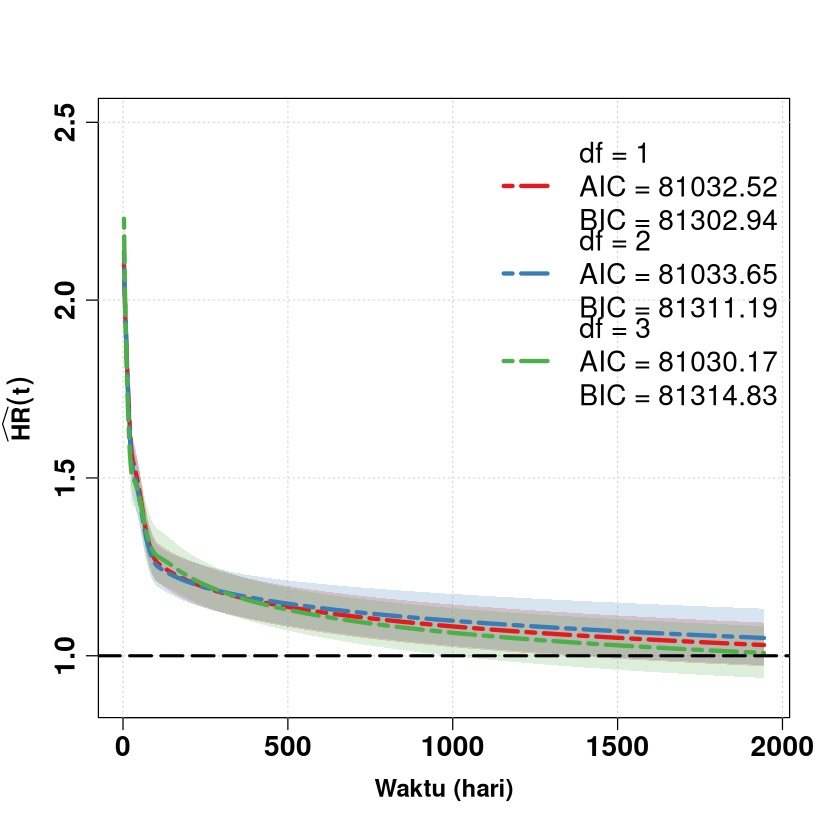

In [13]:
plot_hr_sensitivity(
  hr_scoma, hr_scoma_2, hr_scoma_3,
  model_df1 = fpsm_time,
  model_df2 = fpsm_time_sc_2,
  model_df3 = fpsm_time_sc_3
)

In [19]:
fpsm_time_ca_2 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 2, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))

fpsm_time_ca_1 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 1, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))

In [20]:
hr_cancer <- predict(fpsm_time,
                       newdata  = bd,
                       exposed = function(data) {
                         data$dzclass_Cancer <- 1
                         data
                       },
                       var = "scoma",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_cancer <- hr_cancer %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_cancer_2 <- predict(fpsm_time_ca_2,
                       newdata  = bd,
                       exposed = function(data) {
                         data$dzclass_Cancer <- 1
                         data
                       },
                       var = "scoma",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_cancer_2 <- hr_cancer_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_cancer_1 <- predict(fpsm_time_ca_1,
                       newdata  = bd,
                       exposed = function(data) {
                         data$dzclass_Cancer <- 1
                         data
                       },
                       var = "scoma",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_cancer_1 <- hr_cancer_1 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

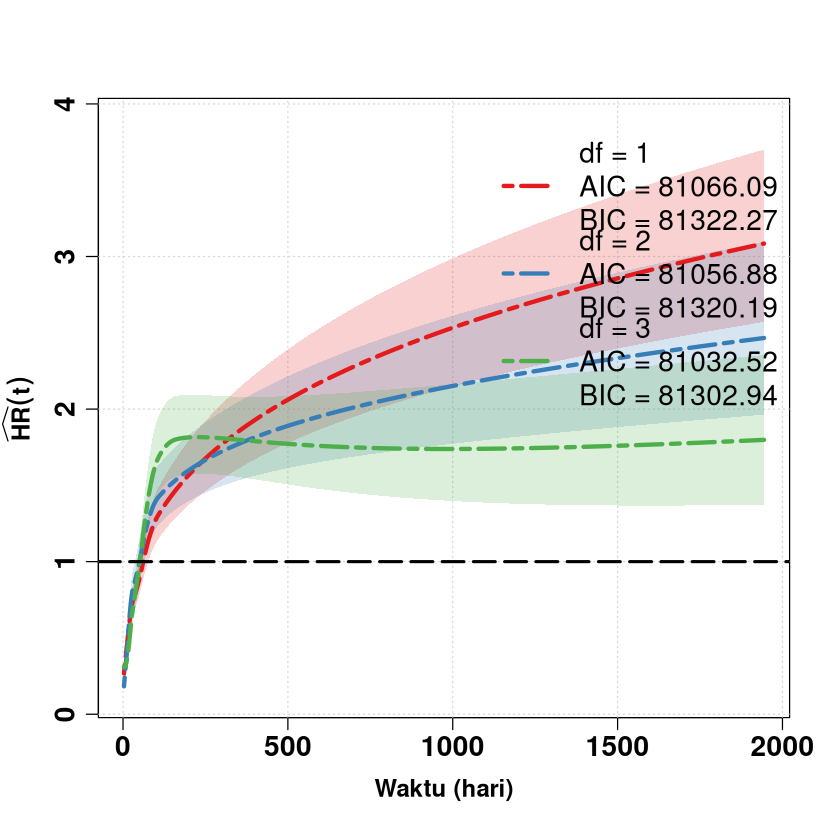

In [21]:
plot_hr_sensitivity(
  hr_cancer_1, hr_cancer_2, hr_cancer,
  model_df1 = fpsm_time_ca_1,
  model_df2 = fpsm_time_ca_2,
  model_df3 = fpsm_time
)

In [22]:
fpsm_time_copd_2 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 2, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))

fpsm_time_copd_3 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 3, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 2))

In [23]:
hr_copd <- predict(fpsm_time,
                       newdata  = bd,
                       var = "dzclass_COPD_CHF_Cirrhosis",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_copd <- hr_copd %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_copd_2 <- predict(fpsm_time_copd_2,
                       newdata  = bd,
                       var = "dzclass_COPD_CHF_Cirrhosis",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_copd_2 <- hr_copd_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_copd_3 <- predict(fpsm_time_copd_3,
                       newdata  = bd,
                       var = "dzclass_COPD_CHF_Cirrhosis",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_copd_3 <- hr_copd_3 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

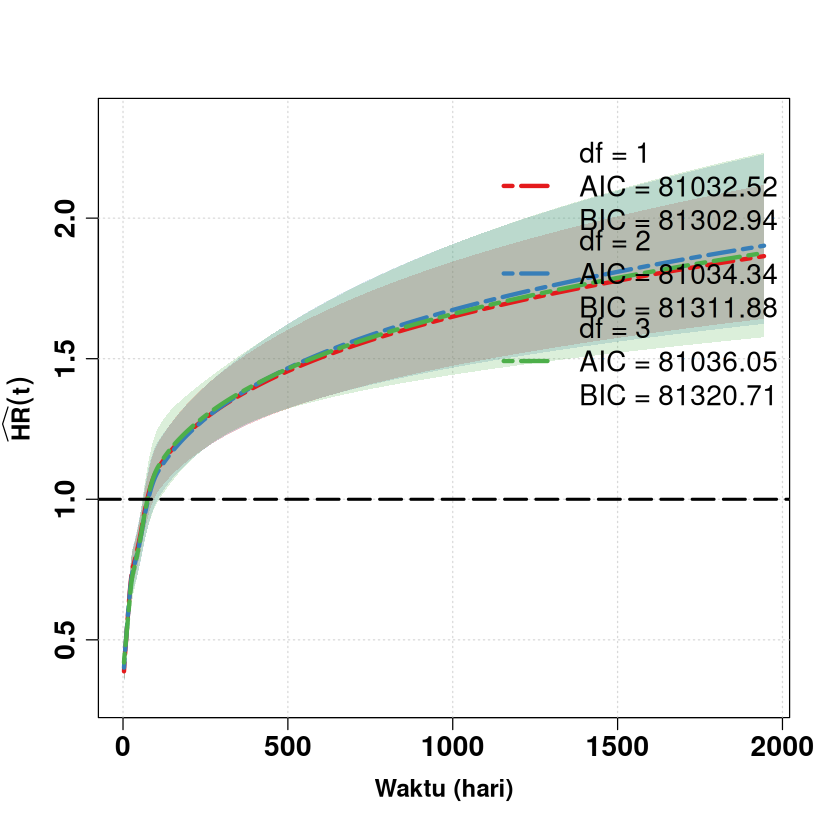

In [24]:
plot_hr_sensitivity(
  hr_copd, hr_copd_2, hr_copd_3,
  model_df1 = fpsm_time,
  model_df2 = fpsm_time_copd_2,
  model_df3 = fpsm_time_copd_3
)

In [25]:
fpsm_time_hday_1 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 1, ph = 2))

fpsm_time_hday_3 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 3, ph = 2))

In [30]:
hr_hday <- predict(fpsm_time,
                       newdata  = bd,
                       exposed = function(data) {
                         data$hday <- 30
                         data
                       },
                       var = "hday",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_hday <- hr_hday %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_hday_1 <- predict(fpsm_time_hday_1,
                       newdata  = bd,
                       exposed = function(data) {
                         data$hday <- 30
                         data
                       },
                       var = "hday",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_hday_1 <- hr_hday_1 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_hday_3 <- predict(fpsm_time_hday_3,
                       newdata  = bd,
                       exposed = function(data) {
                         data$hday <- 30
                         data
                       },
                       var = "hday",
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_hday_3 <- hr_hday_3 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

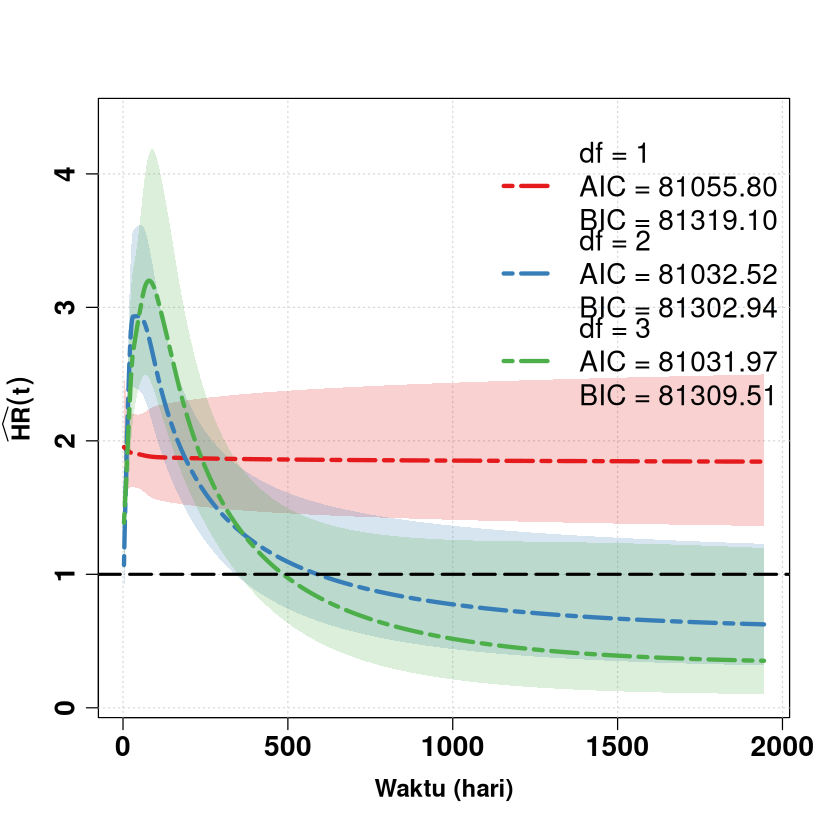

In [29]:
plot_hr_sensitivity(
  hr_hday_1, hr_hday, hr_hday_3,
  model_df1 = fpsm_time_hday_1,
  model_df2 = fpsm_time,
  model_df3 = fpsm_time_hday_3
)

In [31]:
fpsm_time_ph_1 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 1))

fpsm_time_ph_3 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 1, hday = 2, ph = 3))

In [32]:
hr_ph <- predict(fpsm_time,
                       newdata  = bd,
                       exposed = function(data) {
                         data$ph <- 7.2
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_ph <- hr_ph %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_ph_1 <- predict(fpsm_time_ph_1,
                       newdata  = bd,
                       exposed = function(data) {
                         data$ph <- 7.2
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_ph_1 <- hr_ph_1 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_ph_3 <- predict(fpsm_time_ph_3,
                       newdata  = bd,
                       exposed = function(data) {
                         data$ph <- 7.2
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_ph_3 <- hr_ph_3 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

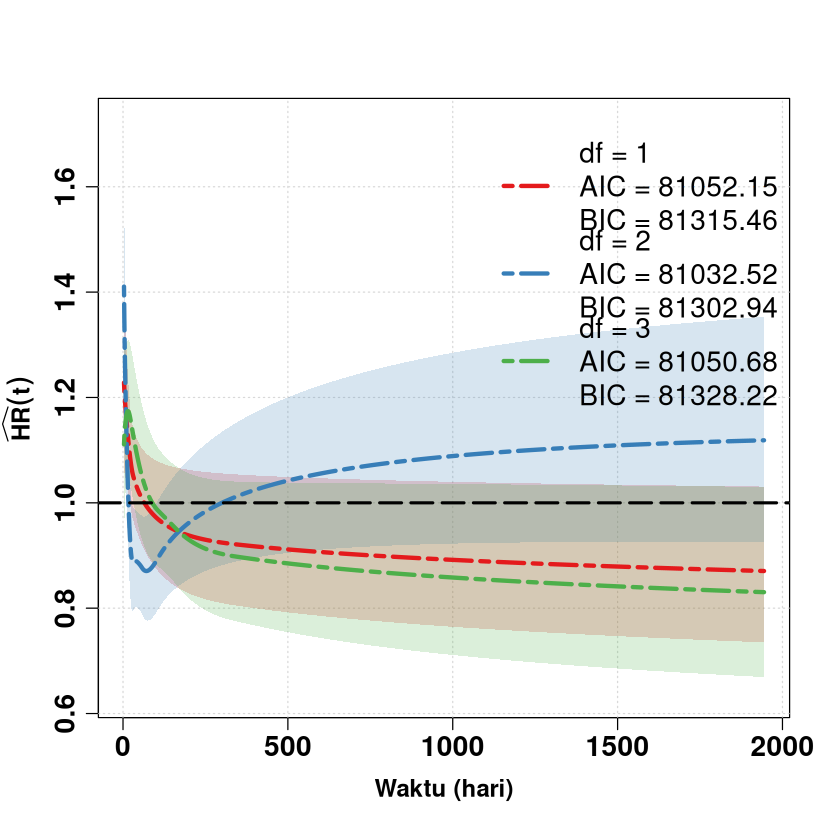

In [33]:
plot_hr_sensitivity(
  hr_ph_1, hr_ph, hr_ph_3,
  model_df1 = fpsm_time_ph_1,
  model_df2 = fpsm_time,
  model_df3 = fpsm_time_ph_3
)

In [34]:
fpsm_time_meanbp_2 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 2, hday = 2, ph = 2))

fpsm_time_meanbp_3 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 1, meanbp = 3, hday = 2, ph = 2))

In [35]:
hr_meanbp <- predict(fpsm_time,
                       newdata  = bd,
                       exposed = function(data) {
                         data$meanbp <- 60
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_meanbp <- hr_meanbp %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_meanbp_2 <- predict(fpsm_time_meanbp_2,
                       newdata  = bd,
                       exposed = function(data) {
                         data$meanbp <- 60
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_meanbp_2 <- hr_meanbp_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_meanbp_3 <- predict(fpsm_time_meanbp_3,
                       newdata  = bd,
                       exposed = function(data) {
                         data$meanbp <- 60
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_meanbp_3 <- hr_meanbp_3 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

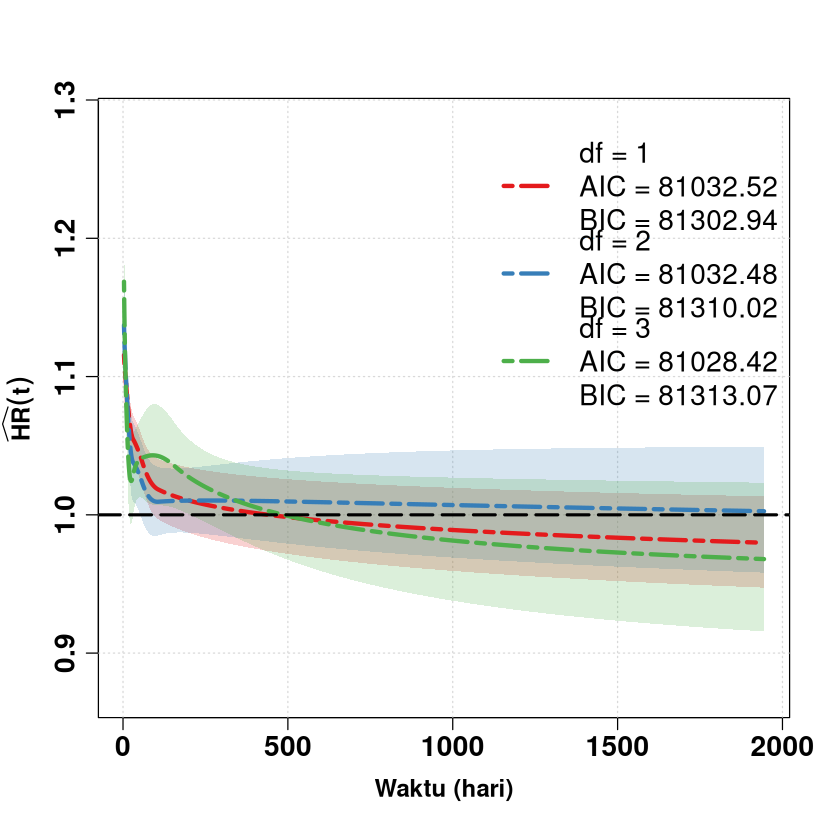

In [36]:
plot_hr_sensitivity(
  hr_meanbp, hr_meanbp_2, hr_meanbp_3,
  model_df1 = fpsm_time,
  model_df2 = fpsm_time_meanbp_2,
  model_df3 = fpsm_time_meanbp_3
)

In [37]:
fpsm_time_bili_2 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 2, meanbp = 1, hday = 2, ph = 2))

fpsm_time_bili_3 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 1, bili = 3, meanbp = 1, hday = 2, ph = 2))

In [38]:
hr_bili <- predict(fpsm_time,
                       newdata  = bd,
                       exposed = function(data) {
                         data$bili <- 2.01
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_bili <- hr_bili %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_bili_2 <- predict(fpsm_time_bili_2,
                       newdata  = bd,
                       exposed = function(data) {
                         data$bili <- 2.01
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_bili_2 <- hr_bili_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_bili_3 <- predict(fpsm_time_bili_3,
                       newdata  = bd,
                       exposed = function(data) {
                         data$bili <- 2.01
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_bili_3 <- hr_bili_3 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

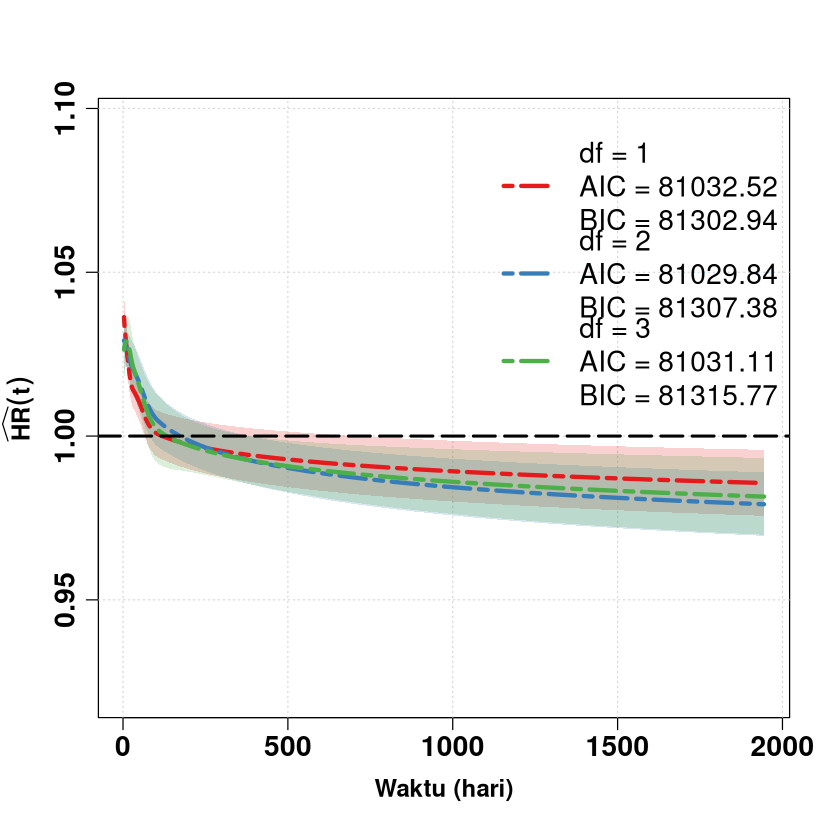

In [39]:
plot_hr_sensitivity(
  hr_bili, hr_bili_2, hr_bili_3,
  model_df1 = fpsm_time,
  model_df2 = fpsm_time_bili_2,
  model_df3 = fpsm_time_bili_3
)

In [40]:
fpsm_time_pafi_2 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 2, bili = 1, meanbp = 1, hday = 2, ph = 2))

fpsm_time_pafi_3 = stpm2(formula = formula_str, df = 5, data = data, 
tvc = list(scoma = 1, dzclass_Cancer = 3, dzclass_COPD_CHF_Cirrhosis = 1, pafi = 3, bili = 1, meanbp = 1, hday = 2, ph = 2))

In [41]:
hr_pafi <- predict(fpsm_time,
                       newdata  = bd,
                       exposed = function(data) {
                         data$pafi <- 100
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_pafi <- hr_pafi %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_pafi_2 <- predict(fpsm_time_pafi_2,
                       newdata  = bd,
                       exposed = function(data) {
                         data$pafi <- 100
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_pafi_2 <- hr_pafi_2 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

hr_pafi_3 <- predict(fpsm_time_pafi_3,
                       newdata  = bd,
                       exposed = function(data) {
                         data$pafi <- 100
                         data
                       },
                       type = "hr", grid = TRUE,
                       se.fit = TRUE, full = TRUE,
                       seqLength = 100000)
hr_pafi_3 <- hr_pafi_3 %>%
  slice(sapply(t_diskrit, function(tp) which.min(abs(d.time - tp)))) %>%
  mutate(t_key = t_diskrit)

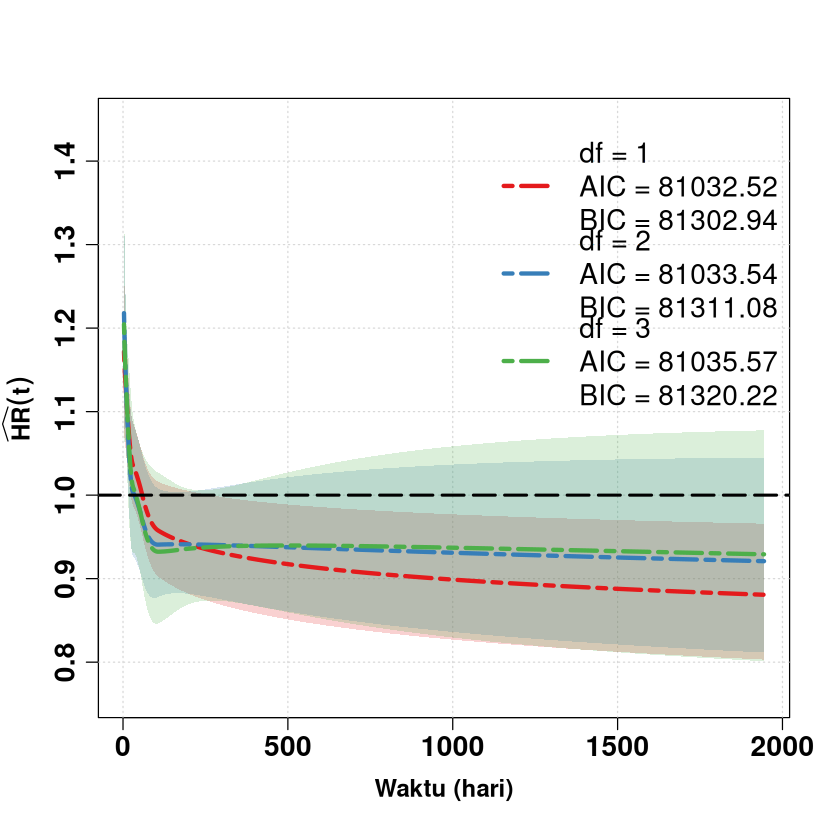

In [42]:
plot_hr_sensitivity(
  hr_pafi, hr_pafi_2, hr_pafi_3,
  model_df1 = fpsm_time,
  model_df2 = fpsm_time_pafi_2,
  model_df3 = fpsm_time_pafi_3
)